# Load ETAS vs thinning ensemble realizations

Load forecast catalogs produced by `runnable_code/catalog_california_etas_vs_thinning_ensemble.py`.

Each realization lives under `<ensemble_dir>/seed_<seed>/` with:
- `etas_catalog.csv`
- `thinning_catalog.csv`
- `summary.csv`

Legacy layouts (`realizations/seed_<seed>/` or `inv_*_seed<start>/` folders) are also discovered when loading.

Set **`ENSEMBLE_DIR`** below, then choose how many realizations to load:
- **`all`** (default) — every `seed_*` folder
- **`first_n`** — the first *n* seeds in sorted order
- **`seeds`** — an explicit list of integer seeds

If `per_realization_metrics.csv` is not yet written (ensemble still running), Tier 1 metrics are **computed in memory** from the loaded catalogs.

In [3]:
%matplotlib inline
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy import stats
from shapely.geometry import Polygon

ETAS_COLOR = "seagreen"
THINNING_COLOR = "indianred"

def show_fig(fig=None):
    """Display a matplotlib figure inline (reliable in notebook UIs)."""
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


In [4]:
def find_repo_root() -> Path:
    """Locate etas repo root even if the kernel cwd is not the repo."""
    for start in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (start / "runnable_code" / "catalog_california_etas_vs_thinning_ensemble.py").is_file():
            return start
        if start.name == "notebooks" and (start.parent / "runnable_code").is_dir():
            return start.parent
    raise FileNotFoundError(
        "Could not find etas repo root. Open this notebook from the etas checkout "
        "and/or set the kernel cwd to the repo or notebooks/ folder."
    )


REPO_ROOT = find_repo_root()

# Optional sibling checkout for catalog_tools (eq_mag_prediction).
for _candidate in [
    REPO_ROOT.parent / "eq_mag_prediction/eq_mag_prediction_clean",
    REPO_ROOT.parent / "eq_mag_prediction",
]:
    if (_candidate / "eq_mag_prediction").is_dir() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

# For Hauksson runs prepared by runnable_code/prepare_hauksson_inputs.py
ENSEMBLES_ROOT = REPO_ROOT / "outputs/hauksson_catalog_etas_vs_thinning/ensembles"

# Explicit ensemble folder, or None = auto-pick newest inv_* dir that has seed_* data
ENSEMBLE_DIR: Path | None = None
# ENSEMBLE_DIR: Path | None = ENSEMBLES_ROOT / "inv_fde4667b33a3b02a"
ENSEMBLE_DIR: Path | None = ENSEMBLES_ROOT / "inv_adfc87cc569b6091"

# --- which realizations to load ---
LOAD_MODE: Literal["all", "first_n", "seeds"] = "all"
FIRST_N: int = 5          # used when LOAD_MODE == "first_n"
SEEDS: list[int] = [100]  # used when LOAD_MODE == "seeds"

# LOAD_MODE: Literal["all", "first_n", "seeds"] = "seeds"
# SEEDS: list[int] = [1905, 1906, 1907, 1908]  # used when LOAD_MODE == "seeds"


In [5]:
def list_ensemble_dirs(ensembles_root: Path) -> list[Path]:
    """``inv_*`` folders under ``ensembles_root`` that contain at least one seed."""
    if not ensembles_root.is_dir():
        return []
    found: list[Path] = []
    for path in ensembles_root.iterdir():
        if not path.is_dir() or not path.name.startswith("inv_"):
            continue
        try:
            discover_realization_seeds(path)
        except FileNotFoundError:
            continue
        found.append(path)
    return sorted(found, key=lambda p: p.stat().st_mtime, reverse=True)


def resolve_ensemble_dir(explicit: Path | None, ensembles_root: Path) -> Path:
    if explicit is not None:
        path = explicit.expanduser()
        if not path.is_absolute():
            path = (REPO_ROOT / path).resolve()
        else:
            path = path.resolve()
        if path.is_dir():
            return path

    candidates = list_ensemble_dirs(ensembles_root)
    lines = "\n".join(f"  - {p}" for p in candidates) if candidates else "  (none)"
    if explicit is not None:
        raise FileNotFoundError(
            f"Ensemble directory not found: {explicit}\n"
            f"REPO_ROOT={REPO_ROOT}\n"
            f"ENSEMBLES_ROOT exists={ensembles_root.is_dir()}\n"
            f"Available ensemble dirs with seed_* data:\n{lines}"
        )
    if not candidates:
        raise FileNotFoundError(
            f"No ensemble output under {ensembles_root.resolve()}.\n"
            "Run runnable_code/catalog_california_etas_vs_thinning_ensemble.py first."
        )
    chosen = candidates[0]
    print(f"Auto-selected ensemble dir: {chosen}")
    return chosen


def discover_realization_seeds(ensemble_dir: Path) -> list[int]:
    """Sorted seeds from ``seed_<seed>/`` (flat or legacy ``realizations/`` layout)."""
    seeds: set[int] = set()
    if not ensemble_dir.is_dir():
        raise FileNotFoundError(f"Not a directory: {ensemble_dir}")

    for path in ensemble_dir.iterdir():
        if path.is_dir() and path.name.startswith("seed_"):
            seeds.add(int(path.name.removeprefix("seed_")))

    legacy = ensemble_dir / "realizations"
    if legacy.is_dir():
        for path in legacy.iterdir():
            if path.is_dir() and path.name.startswith("seed_"):
                seeds.add(int(path.name.removeprefix("seed_")))

    if not seeds:
        raise FileNotFoundError(
            f"No seed_* folders under {ensemble_dir} (or {legacy})"
        )
    return sorted(seeds)


def select_seeds(
    available: list[int],
    *,
    mode: Literal["all", "first_n", "seeds"],
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> list[int]:
    if mode == "all":
        return list(available)
    if mode == "first_n":
        if first_n is None or first_n < 1:
            raise ValueError("first_n must be >= 1 when LOAD_MODE is 'first_n'")
        return available[:first_n]
    if mode == "seeds":
        if not seeds:
            raise ValueError("SEEDS must be non-empty when LOAD_MODE is 'seeds'")
        missing = sorted(set(seeds) - set(available))
        if missing:
            raise ValueError(f"Requested seeds not found: {missing}; available: {available}")
        return [s for s in available if s in set(seeds)]
    raise ValueError(f"Unknown mode: {mode!r}")


def _realization_dir_for_seed(ensemble_dir: Path, seed: int) -> Path:
    flat = ensemble_dir / f"seed_{seed}"
    legacy = ensemble_dir / "realizations" / f"seed_{seed}"
    if flat.is_dir():
        return flat
    if legacy.is_dir():
        return legacy
    return flat


def load_realization_catalogs(ensemble_dir: Path, seed: int) -> dict[str, pd.DataFrame]:
    run_dir = _realization_dir_for_seed(ensemble_dir, seed)
    etas_path = run_dir / "etas_catalog.csv"
    thin_path = run_dir / "thinning_catalog.csv"
    for path in (etas_path, thin_path):
        if not path.is_file():
            raise FileNotFoundError(path)
    etas = pd.read_csv(etas_path)
    thinning = pd.read_csv(thin_path)
    for df in (etas, thinning):
        if "dt_days" in df.columns:
            df["dt_days"] = pd.to_numeric(df["dt_days"], errors="coerce")
        if "m" in df.columns:
            df["m"] = pd.to_numeric(df["m"], errors="coerce")
    return {"etas": etas, "thinning": thinning}


def load_ensemble_realizations(
    ensemble_dir: Path,
    *,
    mode: Literal["all", "first_n", "seeds"] = "all",
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> tuple[dict[int, dict[str, pd.DataFrame]], pd.DataFrame, dict]:
    """Return (catalogs_by_seed, metrics_df, meta)."""
    ensemble_dir = ensemble_dir.resolve()
    available = discover_realization_seeds(ensemble_dir)
    selected = select_seeds(available, mode=mode, first_n=first_n, seeds=seeds)

    meta_path = ensemble_dir / "ensemble_meta.json"
    meta = json.loads(meta_path.read_text(encoding="utf-8")) if meta_path.is_file() else {}

    metrics_path = ensemble_dir / "per_realization_metrics.csv"
    metrics_df = pd.read_csv(metrics_path) if metrics_path.is_file() else pd.DataFrame()
    if not metrics_df.empty and "seed" in metrics_df.columns:
        metrics_df = metrics_df[metrics_df["seed"].isin(selected)].reset_index(drop=True)

    catalogs_by_seed: dict[int, dict[str, pd.DataFrame]] = {}
    for seed in selected:
        catalogs_by_seed[seed] = load_realization_catalogs(ensemble_dir, seed)

    return catalogs_by_seed, metrics_df, meta


_METRIC_COLUMNS = [
    "seed",
    "etas_n_events",
    "thinning_n_events",
    "etas_background",
    "thinning_background",
    "etas_triggered",
    "thinning_triggered",
    "etas_median_iet_days",
    "thinning_median_iet_days",
    "etas_max_magnitude",
    "thinning_max_magnitude",
    "thinning_over_etas_ratio",
]


def realization_metrics_row(
    seed: int,
    etas_catalog: pd.DataFrame,
    thinning_catalog: pd.DataFrame,
) -> dict:
    etas_n = len(etas_catalog)
    thin_n = len(thinning_catalog)
    etas_bg = (
        int((etas_catalog.get("event_source") == "background").sum())
        if "event_source" in etas_catalog.columns
        else np.nan
    )
    thin_bg = int((thinning_catalog["event_source"] == "background").sum())
    etas_trig = (
        int((etas_catalog.get("event_source") == "triggered").sum())
        if "event_source" in etas_catalog.columns
        else np.nan
    )
    thin_trig = int((thinning_catalog["event_source"] == "triggered").sum())
    return {
        "seed": seed,
        "etas_n_events": etas_n,
        "thinning_n_events": thin_n,
        "etas_background": etas_bg,
        "thinning_background": thin_bg,
        "etas_triggered": etas_trig,
        "thinning_triggered": thin_trig,
        "etas_median_iet_days": median_interevent_days(etas_catalog),
        "thinning_median_iet_days": median_interevent_days(thinning_catalog),
        "etas_max_magnitude": float(etas_catalog["m"].max()) if etas_n else np.nan,
        "thinning_max_magnitude": float(thinning_catalog["m"].max()) if thin_n else np.nan,
        "thinning_over_etas_ratio": thin_n / etas_n if etas_n else np.nan,
    }


def compute_metrics_df(
    catalogs_by_seed: dict[int, dict[str, pd.DataFrame]],
    selected_seeds: list[int],
) -> pd.DataFrame:
    rows = [
        realization_metrics_row(seed, catalogs_by_seed[seed]["etas"], catalogs_by_seed[seed]["thinning"])
        for seed in selected_seeds
    ]
    return pd.DataFrame(rows, columns=_METRIC_COLUMNS)


def ensure_metrics_df(
    metrics_df: pd.DataFrame,
    catalogs_by_seed: dict[int, dict[str, pd.DataFrame]],
    selected_seeds: list[int],
) -> pd.DataFrame:
    """Use on-disk metrics when present; otherwise compute and keep in notebook memory."""
    if not metrics_df.empty:
        return metrics_df
    print("per_realization_metrics.csv missing — computing metrics from loaded catalogs.")
    return compute_metrics_df(catalogs_by_seed, selected_seeds)


def cumulative_on_grid(dt_days: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    """Step-function cumulative count N(t) on a uniform day grid."""
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros_like(t_grid, dtype=float)
    return np.searchsorted(np.sort(dt_days), t_grid, side="right").astype(float)


def events_per_time_bin(dt_days: np.ndarray, bin_edges: np.ndarray) -> np.ndarray:
    """Histogram of event counts per time bin (not cumulative)."""
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros(len(bin_edges) - 1, dtype=float)
    counts, _ = np.histogram(dt_days, bins=bin_edges)
    return counts.astype(float)


from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


def ylim_in_xrange(
    xs: np.ndarray,
    ys_list: list[np.ndarray],
    x0: float,
    x1: float,
    *,
    pad_frac: float = 0.08,
) -> tuple[float, float]:
    """Y limits for curves restricted to x in [x0, x1]."""
    mask = (xs >= x0) & (xs <= x1)
    if not np.any(mask):
        return 0.0, 1.0
    vals = [np.asarray(y)[mask] for y in ys_list if np.asarray(y).size == xs.size]
    ymin = min(float(np.min(v)) for v in vals)
    ymax = max(float(np.max(v)) for v in vals)
    pad = max((ymax - ymin) * pad_frac, 1e-6)
    return ymin - pad, ymax + pad


def add_test_window_inset(
    ax,
    x_end: float,
    draw_fn,
    *,
    loc: str = "upper left",
    ylims: tuple[float, float] | None = None,
) -> None:
    """Inset zoomed to forecast test window [0, x_end] (days since forecast start)."""
    axins = inset_axes(ax, width="38%", height="38%", loc=loc, borderpad=0.9)
    draw_fn(axins)
    axins.set_xlim(0.0, x_end)
    if ylims is not None:
        axins.set_ylim(*ylims)
    axins.tick_params(labelsize=7)
    axins.grid(True, alpha=0.3)
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.45", ls=":", lw=0.8)


def draw_cumulative_event_count(
    ax,
    *,
    t_grid: np.ndarray,
    etas_curves: np.ndarray,
    thin_curves: np.ndarray,
    etas_slope: float,
    thin_slope: float,
    train_dt_days: np.ndarray,
    train_days: float,
    show_training_slopes: bool = True,
    show_legend: bool = False,
) -> None:
    for label, arr, color, slope in [
        ("ETAS", etas_curves, ETAS_COLOR, etas_slope),
        ("Thinning", thin_curves, THINNING_COLOR, thin_slope),
    ]:
        mean = arr.mean(axis=0)
        if arr.shape[0] > 1:
            q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
        else:
            q25 = q75 = mean
        ax.fill_between(t_grid, q25, q75, color=color, alpha=0.2, zorder=2)
        legend_label = (
            f"{label} mean ({slope:.3f} events/day, n={arr.shape[0]})" if show_legend else None
        )
        ax.plot(
            t_grid,
            mean,
            color=color,
            lw=2.0,
            zorder=3,
            label=legend_label,
        )
    if train_dt_days.size:
        train_curve = cumulative_on_grid(train_dt_days, t_grid)
        ax.plot(
            t_grid,
            train_curve,
            color="black",
            lw=2.0,
            ls="--",
            zorder=4,
            label=f"Training (n={train_dt_days.size})" if show_legend else None,
        )
        if show_training_slopes:
            train_mask = t_grid < 0.0
            mark_idx = np.linspace(0, train_mask.sum() - 1, num=min(8, train_mask.sum()), dtype=int)
            mark_t = t_grid[train_mask][mark_idx]
            mark_y = train_curve[train_mask][mark_idx]
            segment_days = min(0.2 * train_days, 365.0) if train_days > 0 else 30.0
            for t0, y0 in zip(mark_t, mark_y):
                ax.plot(
                    [t0, t0 + segment_days],
                    [y0, y0 + etas_slope * segment_days],
                    color=ETAS_COLOR,
                    lw=1.5,
                    alpha=0.7,
                    zorder=5,
                )
                ax.plot(
                    [t0, t0 + segment_days],
                    [y0, y0 + thin_slope * segment_days],
                    color=THINNING_COLOR,
                    lw=1.5,
                    alpha=0.7,
                    zorder=5,
                )
            if show_legend:
                ax.plot([], [], color=ETAS_COLOR, lw=1.5, alpha=0.7, label="ETAS slope on training")
                ax.plot([], [], color=THINNING_COLOR, lw=1.5, alpha=0.7, label="Thinning slope on training")
    ax.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7, zorder=1)


def draw_event_rate_by_bin(
    ax,
    *,
    bin_centers: np.ndarray,
    bin_edges: np.ndarray,
    etas_bin_curves: np.ndarray,
    thin_bin_curves: np.ndarray,
    train_dt_days: np.ndarray,
    bin_length_days: float,
    include_training: bool = True,
    show_legend: bool = False,
) -> None:
    for label, arr, color in [
        ("ETAS", etas_bin_curves, ETAS_COLOR),
        ("Thinning", thin_bin_curves, THINNING_COLOR),
    ]:
        ax.plot(
            bin_centers,
            arr.mean(axis=0),
            color=color,
            lw=2.0,
            label=f"{label} mean per bin" if show_legend else None,
        )
    if include_training and train_dt_days.size:
        train_bin_counts = events_per_time_bin(train_dt_days, bin_edges)
        neg_bin_mask = bin_edges[:-1] < 0.0
        train_centers_neg = bin_centers[neg_bin_mask]
        train_counts_neg = train_bin_counts[neg_bin_mask]
        ax.plot(
            train_centers_neg,
            train_counts_neg,
            color="black",
            lw=2.0,
            ls="--",
            label="Training" if show_legend else None,
        )
        train_ma_window_bins = max(20, int(round(90.0 / bin_length_days)))
        train_counts_smooth = (
            pd.Series(train_counts_neg)
            .rolling(train_ma_window_bins, center=True, min_periods=1)
            .mean()
            .to_numpy()
        )
        ax.plot(
            train_centers_neg,
            train_counts_smooth,
            color="yellow",
            lw=1.8,
            alpha=0.85,
            label=f"Training moving avg ({train_ma_window_bins} bins)" if show_legend else None,
        )
    ax.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7, zorder=1)


def interevent_times(event_time_days: np.ndarray) -> np.ndarray:
    """Successive gaps [days] between sorted event times (any common time origin)."""
    event_time_days = np.sort(event_time_days[np.isfinite(event_time_days)])
    if event_time_days.size < 2:
        return np.array([], dtype=float)
    return np.diff(event_time_days)


def median_interevent_days(catalog: pd.DataFrame) -> float:
    if "dt_days" not in catalog.columns or len(catalog) < 2:
        return np.nan
    iet = interevent_times(catalog["dt_days"].to_numpy(dtype=float))
    return float(np.median(iet)) if iet.size else np.nan


def nearest_neighbor_distances_km(cat: pd.DataFrame) -> np.ndarray:
    import etas.utility_functions as utility_functions

    y = cat["y"].to_numpy(dtype=float)
    x = cat["x"].to_numpy(dtype=float)
    n = len(y)
    if n < 2:
        return np.array([], dtype=float)
    dists = np.empty(n, dtype=float)
    for i in range(n):
        d2 = utility_functions.spatial_distance_squared_km2(y, x, y[i], x[i])
        d2[i] = np.inf
        dists[i] = np.sqrt(np.min(d2))
    return dists


def etas_parent_distances_km(cat: pd.DataFrame) -> np.ndarray:
    import etas.utility_functions as utility_functions

    if "parent_latitude" not in cat.columns or "parent_longitude" not in cat.columns:
        return np.array([], dtype=float)
    if "event_source" in cat.columns:
        triggered = cat[cat["event_source"] == "triggered"]
    elif "is_background" in cat.columns:
        triggered = cat[~cat["is_background"].astype(bool)]
    else:
        triggered = cat
    if triggered.empty:
        return np.array([], dtype=float)
    dists = [
        float(np.sqrt(utility_functions.spatial_distance_squared_km2(
            row["y"], row["x"], row["parent_latitude"], row["parent_longitude"]
        )))
        for _, row in triggered.iterrows()
    ]
    return np.asarray(dists, dtype=float)


_continuation_module = None


def load_continuation_module():
    global _continuation_module
    if _continuation_module is not None:
        return _continuation_module
    path = REPO_ROOT / "runnable_code/catalog_california_etas_vs_thinning_continuation.py"
    spec = importlib.util.spec_from_file_location("catalog_california_etas_vs_thinning_continuation", path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not load continuation module from {path}")
    mod = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = mod
    spec.loader.exec_module(mod)
    _continuation_module = mod
    return mod


def load_intensity_context(
    ensemble_dir: Path,
    meta: dict,
    seed: int,
) -> dict:
    """Polygon, ETAS parameters, and history for λ(t) / parent-distance helpers."""
    from etas.inversion import ETASParameterCalculation

    cat_cmp = load_continuation_module()
    realization_meta_path = _realization_dir_for_seed(ensemble_dir, seed) / "realization_meta.json"
    rmeta = (
        json.loads(realization_meta_path.read_text(encoding="utf-8"))
        if realization_meta_path.is_file()
        else {}
    )
    inv_id = meta.get("inversion_id") or rmeta.get("inversion_id")
    if not inv_id:
        raise ValueError("Could not determine inversion_id from meta or realization_meta.json")
    a_h_resolution = int(meta.get("a_h_resolution") or rmeta.get("a_h_resolution", 500))

    # Prefer the exact path recorded by the ensemble driver (works for non-California outputs).
    params_json = None
    meta_params = meta.get("parameters_json")
    if meta_params:
        candidate = Path(meta_params)
        if not candidate.is_absolute():
            candidate = (REPO_ROOT / candidate).resolve()
        if candidate.is_file():
            params_json = candidate

    if params_json is None:
        inv_dir = REPO_ROOT / "outputs/catalog_etas_vs_thinning/inversions" / f"inv_{inv_id}"
        params_json = inv_dir / f"parameters_{inv_id}.json"

    if not params_json.is_file():
        raise FileNotFoundError(f"Inversion parameters not found: {params_json}")

    inversion_output = json.loads(params_json.read_text(encoding="utf-8"))
    etas_inversion = ETASParameterCalculation.load_calculation(inversion_output)
    theta_0 = cat_cmp.expand_theta_log10(dict(etas_inversion.theta))
    mc = float(etas_inversion.m_ref - etas_inversion.delta_m / 2)
    theta_0["m_c"] = mc
    polygon = Polygon(etas_inversion.shape_coords)

    source_events = etas_inversion.source_events.copy()
    if "xi_plus_1" not in source_events.columns:
        source_events["xi_plus_1"] = 1.0
    auxiliary_catalog = pd.merge(
        source_events,
        etas_inversion.catalog[["latitude", "longitude", "time", "magnitude"]],
        left_index=True,
        right_index=True,
        how="left",
    )
    timewindow_end = meta.get("timewindow_end") or rmeta.get("timewindow_end")
    testwindow_end = meta.get("testwindow_end") or rmeta.get("testwindow_end")
    forecast_start_dt = pd.to_datetime(timewindow_end, utc=True).tz_convert(None)
    forecast_end_dt = pd.to_datetime(testwindow_end, utc=True).tz_convert(None)

    history_df = auxiliary_catalog.loc[auxiliary_catalog["time"] <= forecast_start_dt].copy()
    history_df = history_df.sort_values("time").reset_index(drop=True)
    history_df["t"] = (history_df["time"] - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    history_df["x"] = history_df["longitude"].astype(float)
    history_df["y"] = history_df["latitude"].astype(float)
    history_df["m"] = history_df["magnitude"].astype(float)

    forecast_start_t = float(history_df["t"].max()) if len(history_df) else (
        (forecast_start_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    )
    forecast_end_t = (forecast_end_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    hist_events = [cat_cmp.to_history_dict(row) for _, row in history_df.iterrows()]

    return {
        "module": cat_cmp,
        "polygon": polygon,
        "theta_0": theta_0,
        "mc": mc,
        "beta_main": float(etas_inversion.beta),
        "a_h_resolution": a_h_resolution,
        "history_df": history_df,
        "hist_events": hist_events,
        "forecast_start_t": forecast_start_t,
        "forecast_end_t": forecast_end_t,
        "forecast_days": forecast_end_t - forecast_start_t,
    }


def thinning_dominant_parent_distances_km(cat: pd.DataFrame, ctx: dict) -> np.ndarray:
    """Distance to the dominant triggering parent at each event time (thinning logic)."""
    import etas.utility_functions as utility_functions

    cat_cmp = ctx["module"]
    poly = ctx["polygon"]
    params = ctx["theta_0"]
    resolution = ctx["a_h_resolution"]
    events = list(ctx["hist_events"])

    triggered = cat[cat["event_source"] == "triggered"] if "event_source" in cat.columns else cat
    dists: list[float] = []
    for _, row in triggered.iterrows():
        t = float(row["t"])
        contribs = [
            cat_cmp.A_h(poly, h, params, resolution) * cat_cmp.g(t, h, params)
            for h in events
            if h["t"] < t
        ]
        if not contribs:
            continue
        parent = events[int(np.argmax(contribs))]
        d2 = utility_functions.spatial_distance_squared_km2(
            float(row["y"]), float(row["x"]), parent["y"], parent["x"]
        )
        dists.append(float(np.sqrt(d2)))
        events.append(
            {"m": float(row["m"]), "x": float(row["x"]), "y": float(row["y"]), "t": t}
        )
    return np.asarray(dists, dtype=float)


def lambda_on_grid(cat: pd.DataFrame, ctx: dict, t_grid: np.ndarray) -> np.ndarray:
    cat_cmp = ctx["module"]
    evs = cat_cmp._events_from_catalog(cat, ctx["hist_events"])
    return np.array([
        cat_cmp.lambda_s_total(t, evs, ctx["polygon"], ctx["theta_0"], ctx["a_h_resolution"])
        for t in t_grid
    ])


def integrated_lambda(lam: np.ndarray, t_grid: np.ndarray) -> float:
    return float(np.trapz(lam, t_grid))


def l2_curve_distance(curve_a: np.ndarray, curve_b: np.ndarray, t_grid: np.ndarray) -> float:
    diff = curve_a - curve_b
    return float(np.sqrt(np.trapz(diff * diff, t_grid)))


def resolve_meta_catalog_path(meta: dict) -> Path:
    """Full observed catalog CSV recorded in ensemble meta (or its source config)."""
    catalog_path = meta.get("catalog") or meta.get("fn_catalog")
    if not catalog_path:
        config_path = meta.get("config")
        if config_path:
            cfg_path = Path(config_path)
            if not cfg_path.is_absolute():
                cfg_path = (REPO_ROOT / cfg_path).resolve()
            if cfg_path.is_file():
                catalog_path = json.loads(cfg_path.read_text(encoding="utf-8")).get("fn_catalog")
    if not catalog_path:
        raise ValueError("Could not resolve observed catalog path from ensemble meta")
    path = Path(catalog_path)
    if not path.is_absolute():
        path = (REPO_ROOT / path).resolve()
    if not path.is_file():
        raise FileNotFoundError(f"Observed catalog not found: {path}")
    return path


def prepare_catalog_for_analysis(cat: pd.DataFrame) -> pd.DataFrame:
    """Standard columns for catalog_tools and spatial helpers."""
    out = cat.sort_values("time").reset_index(drop=True).copy()
    out["x"] = out["longitude"].astype(float)
    out["y"] = out["latitude"].astype(float)
    if "m" not in out.columns and "magnitude" in out.columns:
        out["m"] = out["magnitude"].astype(float)
    return out


def event_times_days_since_window_start(cat: pd.DataFrame) -> np.ndarray:
    if cat.empty:
        return np.array([], dtype=float)
    t0 = cat["time"].iloc[0]
    return ((cat["time"] - t0) / pd.Timedelta("1D")).to_numpy(dtype=float)


def subsample_catalog(cat: pd.DataFrame, max_events: int = 5000, seed: int = 0) -> pd.DataFrame:
    """Random subsample for expensive O(n^2) distribution plots on large catalogs."""
    if len(cat) <= max_events:
        return cat
    return cat.sample(n=max_events, random_state=seed).sort_values("time").reset_index(drop=True)


def load_observed_train_test_catalogs(meta: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Observed events in training and held-out test windows from the source catalog."""
    raw = pd.read_csv(resolve_meta_catalog_path(meta))
    raw["time"] = pd.to_datetime(raw["time"], utc=True, format="mixed").dt.tz_convert(None)

    tw_start = pd.to_datetime(meta["timewindow_start"], utc=True).tz_convert(None)
    tw_end = pd.to_datetime(meta["timewindow_end"], utc=True).tz_convert(None)
    test_end = pd.to_datetime(meta["testwindow_end"], utc=True).tz_convert(None)

    train = prepare_catalog_for_analysis(
        raw.loc[(raw["time"] >= tw_start) & (raw["time"] <= tw_end)]
    )
    test = prepare_catalog_for_analysis(
        raw.loc[(raw["time"] > tw_end) & (raw["time"] <= test_end)]
    )
    return train, test


In [6]:
ensemble_dir = resolve_ensemble_dir(ENSEMBLE_DIR, ENSEMBLES_ROOT)

available_seeds = discover_realization_seeds(ensemble_dir)
selected_seeds = select_seeds(
    available_seeds,
    mode=LOAD_MODE,
    first_n=FIRST_N,
    seeds=SEEDS,
)

catalogs_by_seed, metrics_df, meta = load_ensemble_realizations(
    ensemble_dir,
    mode=LOAD_MODE,
    first_n=FIRST_N,
    seeds=SEEDS,
)
metrics_df = ensure_metrics_df(metrics_df, catalogs_by_seed, selected_seeds)

display(Markdown(f"**REPO_ROOT:** `{REPO_ROOT}`"))
display(Markdown(f"**Ensemble dir:** `{ensemble_dir}`"))
display(Markdown(f"**Available seeds:** {available_seeds}"))
display(Markdown(f"**Loaded seeds ({LOAD_MODE}):** {selected_seeds}"))
if meta:
    display(Markdown(
        f"Forecast window: `{meta.get('timewindow_end')}` → `{meta.get('testwindow_end')}` "
        f"({meta.get('forecast_days', '?')} days)"
    ))

metrics_df


FileNotFoundError: Ensemble directory not found: /home/neriberman/Repos/etas/outputs/hauksson_catalog_etas_vs_thinning/ensembles/inv_adfc87cc569b6091
REPO_ROOT=/home/neriberman/Repos/etas
ENSEMBLES_ROOT exists=True
Available ensemble dirs with seed_* data:
  - /home/neriberman/Repos/etas/outputs/hauksson_catalog_etas_vs_thinning/ensembles/inv_fde4667b33a3b02a
  - /home/neriberman/Repos/etas/outputs/hauksson_catalog_etas_vs_thinning/ensembles/inv_a8e1b447162b3b88

In [ ]:
# Convenience views for interactive analysis
etas_by_seed = {seed: catalogs["etas"] for seed, catalogs in catalogs_by_seed.items()}
thinning_by_seed = {seed: catalogs["thinning"] for seed, catalogs in catalogs_by_seed.items()}

# Example: peek at one realization
example_seed = selected_seeds[0]
print(f"ETAS catalog (seed={example_seed}), n={len(etas_by_seed[example_seed])}")
display(etas_by_seed[example_seed].head())
print(f"Thinning catalog (seed={example_seed}), n={len(thinning_by_seed[example_seed])}")
display(thinning_by_seed[example_seed].head())


ETAS catalog (seed=0), n=206


,G,angle,degree_lat,degree_lon,evt_id,expected_n_aftershocks,gen_0_parent,generation,is_background,l_hat,...,source_to_end_time_distance,time,time_delta,xi_plus_1,t,dt_days,x,y,m,event_source
0,NaN,NaN,NaN,NaN,2137.0,1.781978,1,0,True,NaN,...,NaN,2016-06-08 09:21:55.700140000,NaN,1.0,16960.390228,52.219117,-121.131622,36.837355,4.843617,background
1,NaN,1.334353,111.318845,89.092591,NaN,0.888031,1,1,False,NaN,...,NaN,2016-06-08 15:31:20.476940534,0.256537,1.0,16960.646765,52.475654,-121.110079,36.841509,4.271436,triggered
2,NaN,5.570004,111.318845,89.087752,NaN,0.987816,1,2,False,NaN,...,NaN,2016-06-08 15:46:10.070149312,0.010296,1.0,16960.657061,52.485950,-121.112459,36.843711,4.358922,triggered
3,NaN,1.034153,111.318845,89.087752,NaN,0.707967,1,2,False,NaN,...,NaN,2016-06-15 09:41:31.025772533,6.757067,1.0,16967.403831,59.232720,-121.101283,36.845697,4.085268,triggered
4,NaN,3.714563,111.318845,89.092591,NaN,0.421919,1,1,False,NaN,...,NaN,2016-06-15 16:25:05.791784372,7.293867,1.0,16967.684095,59.512984,-121.141317,36.825328,3.660050,triggered


Thinning catalog (seed=0), n=178


,latitude,longitude,magnitude,time,is_background,t,dt_days,x,y,m,event_source
0,31.645153,-120.498033,3.627285,2016-05-24 08:24:49.210374674,True,16945.350570,37.179458,-120.498033,31.645153,3.627285,background
1,36.091972,-117.839334,3.615335,2016-05-28 12:32:53.476863023,False,16949.522841,41.351730,-117.839334,36.091972,3.615335,triggered
2,31.599488,-114.188503,3.827808,2016-06-02 16:34:17.573421547,True,16954.690481,46.519370,-114.188503,31.599488,3.827808,background
3,34.195810,-117.407320,3.605527,2016-06-14 08:01:22.951458217,False,16966.334293,58.163182,-117.407320,34.195810,3.605527,triggered
4,34.193574,-117.408718,4.713914,2016-06-20 03:15:14.523873370,False,16972.135585,63.964474,-117.408718,34.193574,4.713914,triggered


## Raw observed data (train / test)

Before comparing ETAS vs thinning forecasts, inspect the **observed** catalogs:

- **Training:** `[timewindow_start, timewindow_end]` — events used for ETAS inversion
- **Test:** `(timewindow_end, testwindow_end]` — held-out events in the forecast window

Plots use `catalog_tools` from `eq_mag_prediction.utilities.catalog_methods` (magnitude vs time, spatial map, and distributional summaries).

2026-07-07 23:00:19,532 - INFO - Loading Calculation...
2026-07-07 23:00:19,533 - INFO -   model is named NoName ETAS Model, has ID fde4667b33a3b02a
2026-07-07 23:00:19,534 - INFO -   Time Window: 
      1981-01-01 00:00:00 (aux start)
      2009-02-03 00:00:00 (start)
      2016-05-23 23:05:46 (end).
2026-07-07 23:00:19,534 - INFO -   free_productivity: False, free_background: False
2026-07-07 23:00:19,749 - INFO -   202664 out of 266662 events are within time window.
2026-07-07 23:00:19,751 - INFO -   Coordinates of region: [array([  30.8615, -122.215 ]), array([  30.8615, -113.995 ]), array([  38.541, -113.995]), array([  38.541, -122.215]), array([  30.8615, -122.215 ])]
2026-07-07 23:00:20,071 - INFO - Region has 640397.3942796533 square km
2026-07-07 23:00:20,072 - INFO - 202664 events lie within target region.
2026-07-07 23:00:20,081 - DEBUG -   Checking for rounding issues...
2026-07-07 23:00:20,083 - DEBUG -   No rounding issues found.
2026-07-07 23:00:20,085 - INFO - 2135 eve

**Training:** `2009-02-03  00:00:00` → `2016-05-23 23:05:46` (47693 events)  
**Test:** `2016-05-23 23:05:46` → `2020-01-01 00:00:00` (43891 events)

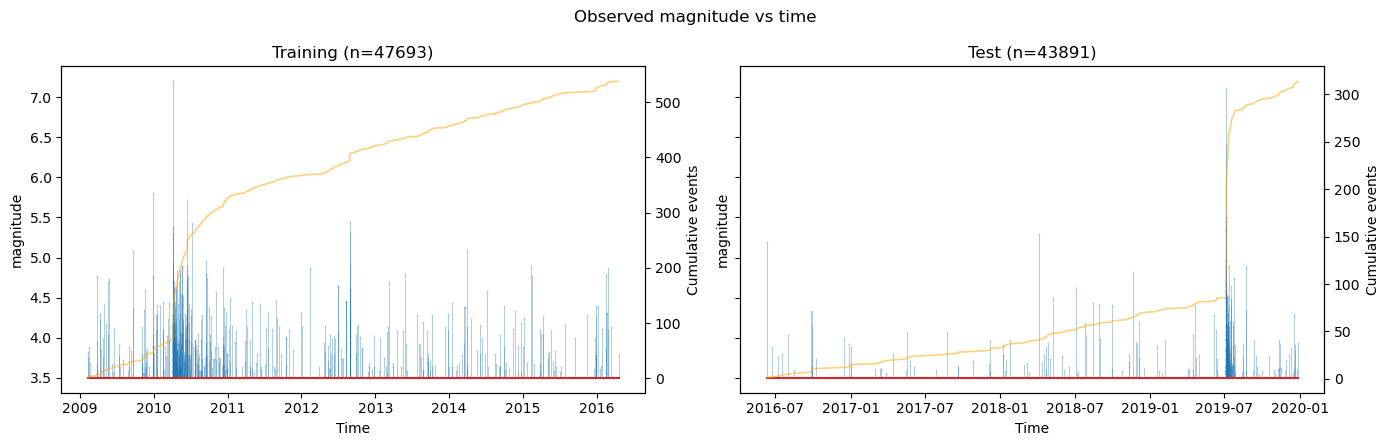

Setting extent: [-123.215  -112.995    30.2405   39.541 ]
Setting extent: [-122.37783 -114.04767   29.8615    38.5885 ]


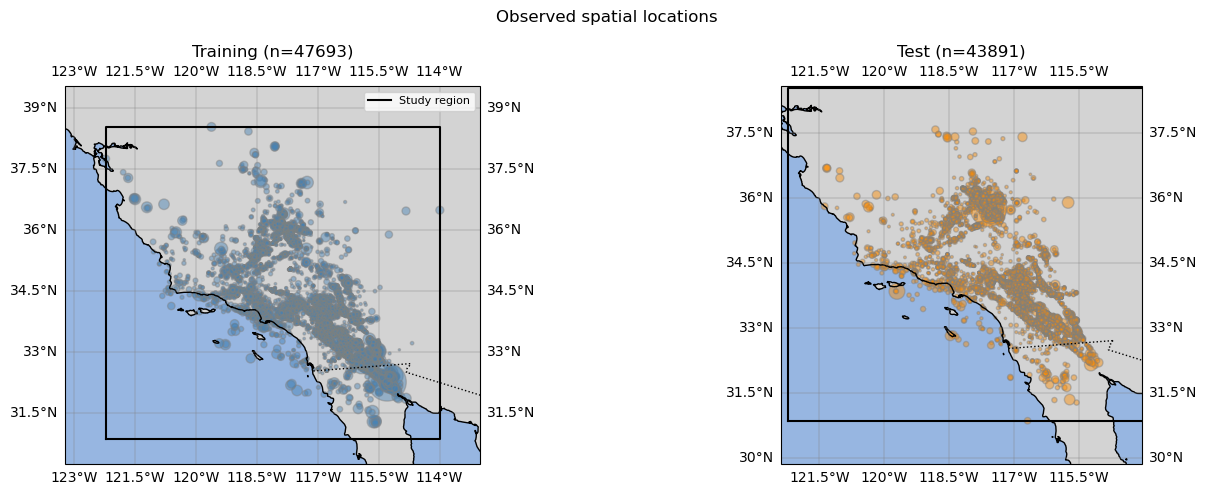

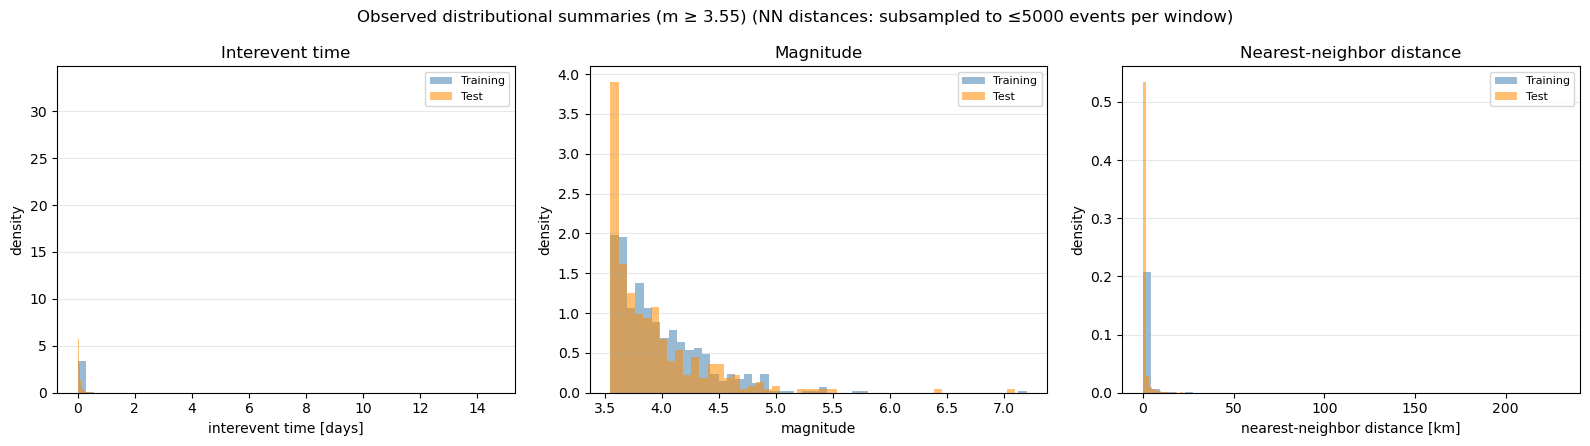

In [ ]:
import eq_mag_prediction.utilities.catalog_methods  # noqa: F401 — registers .catalog_tools
from cartopy import crs as ccrs

TRAIN_COLOR = "steelblue"
TEST_COLOR = "darkorange"

if not meta:
    raise ValueError("ensemble meta is empty — run the load cell above first")

train_catalog, test_catalog = load_observed_train_test_catalogs(meta)
observed_mc = float(meta["mc"]) if meta.get("mc") not in (None, "") else None
run_ctx = load_intensity_context(ensemble_dir, meta, selected_seeds[0])
run_polygon = run_ctx["polygon"]
cat_cmp = load_continuation_module()
combined_catalog = pd.concat([train_catalog, test_catalog], ignore_index=True)

display(
    Markdown(
        f"**Training:** `{meta.get('timewindow_start')}` → `{meta.get('timewindow_end')}` "
        f"({len(train_catalog)} events)  \n"
        f"**Test:** `{meta.get('timewindow_end')}` → `{meta.get('testwindow_end')}` "
        f"({len(test_catalog)} events)"
    )
)

# --- magnitude vs time ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, cat, label in [
    (axes[0], train_catalog, "Training"),
    (axes[1], test_catalog, "Test"),
]:
    if cat.empty:
        ax.set_title(f"{label} (no events)")
        ax.set_xlabel("Time")
        ax.set_ylabel("magnitude")
        continue
    cat.catalog_tools.plot_time_series(
        "magnitude",
        completeness=observed_mc,
        ax=ax,
    )
    ax.set_title(f"{label} (n={len(cat)})")
fig.suptitle("Observed magnitude vs time", fontsize=12)
fig.tight_layout()
show_fig(fig)

# --- spatial locations ---
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
for i, (ax, cat, label, color) in enumerate([
    (axes[0], train_catalog, "Training", TRAIN_COLOR),
    (axes[1], test_catalog, "Test", TEST_COLOR),
]):
    if cat.empty:
        combined_catalog.catalog_tools.plot_base_map(ax=ax)
        ax.set_title(f"{label} (no events)")
    else:
        cat.catalog_tools.plot_map(ax=ax, c=color, alpha=0.45)
        ax.set_title(f"{label} (n={len(cat)})")
    cat_cmp.plot_polygon_map(
        ax,
        run_polygon,
        color="black",
        linewidth=1.5,
        transform=ccrs.PlateCarree(),
        zorder=10,
        label="Study region" if i == 0 else None,
    )
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Observed spatial locations", fontsize=12)
fig.tight_layout()
show_fig(fig)

# --- distributions (interevent time, magnitude, nearest-neighbor distance) ---
train_iet = interevent_times(event_times_days_since_window_start(train_catalog))
test_iet = interevent_times(event_times_days_since_window_start(test_catalog))
train_m = train_catalog["magnitude"].to_numpy(dtype=float) if not train_catalog.empty else np.array([])
test_m = test_catalog["magnitude"].to_numpy(dtype=float) if not test_catalog.empty else np.array([])
if observed_mc is not None:
    train_m = train_m[train_m >= observed_mc]
    test_m = test_m[test_m >= observed_mc]
train_nn = nearest_neighbor_distances_km(subsample_catalog(train_catalog))
test_nn = nearest_neighbor_distances_km(subsample_catalog(test_catalog))
nn_note = ""
if len(train_catalog) > 5000 or len(test_catalog) > 5000:
    nn_note = " (NN distances: subsampled to ≤5000 events per window)"

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, train_data, test_data, xlabel, title in [
    (axes[0], train_iet, test_iet, "interevent time [days]", "Interevent time"),
    (axes[1], train_m, test_m, "magnitude", "Magnitude"),
    (axes[2], train_nn, test_nn, "nearest-neighbor distance [km]", "Nearest-neighbor distance"),
]:
    if train_data.size:
        ax.hist(train_data, bins=50, density=True, alpha=0.55, color=TRAIN_COLOR, label="Training")
    if test_data.size:
        ax.hist(test_data, bins=50, density=True, alpha=0.55, color=TEST_COLOR, label="Test")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

mag_note = f" (m ≥ {observed_mc:.2f})" if observed_mc is not None else ""
fig.suptitle(f"Observed distributional summaries{mag_note}{nn_note}", fontsize=12)
fig.tight_layout()
show_fig(fig)


## ETAS vs thinning comparison

**Tier 1 — scalar summaries:** event counts, ratio, background/triggered fractions, median interevent time, max magnitude, cumulative N(t), and events per time bin.

**Tier 2 — distributional:** interevent times, nearest-neighbor distances, distance to triggering parent.

**Tier 3 — mechanistic:** conditional intensity λ(t) and integrated-rate consistency.

**Formal tests:** paired Wilcoxon on counts, KS on timing/magnitude, permutation test on mean count difference; N(t) mean-curve difference and per-seed L2 distance.

In [ ]:
forecast_days = float(meta.get("forecast_days", np.nan))
if not np.isfinite(forecast_days):
    all_dt = np.concatenate([
        df["dt_days"].to_numpy()
        for catalogs in catalogs_by_seed.values()
        for df in catalogs.values()
    ])
    forecast_days = float(np.nanmax(all_dt)) if all_dt.size else 1.0

# Training catalog: inversion events in [timewindow_start, timewindow_end], dt_days < 0 at forecast start
timewindow_start = meta.get("timewindow_start")
timewindow_end = meta.get("timewindow_end")
train_dt_days = np.array([], dtype=float)
train_days = 0.0
if timewindow_start and timewindow_end:
    _train_ctx = load_intensity_context(ensemble_dir, meta, selected_seeds[0])
    _train_start_dt = pd.to_datetime(timewindow_start, utc=True).tz_convert(None)
    _train_end_dt = pd.to_datetime(timewindow_end, utc=True).tz_convert(None)
    _train_df = _train_ctx["history_df"].loc[
        (_train_ctx["history_df"]["time"] >= _train_start_dt)
        & (_train_ctx["history_df"]["time"] <= _train_end_dt)
    ]
    _forecast_start_t = _train_ctx["forecast_start_t"]
    train_dt_days = (_train_df["t"].to_numpy(dtype=float) - _forecast_start_t)
    train_days = float((_train_end_dt - _train_start_dt).total_seconds() / 86400.0)

t_grid = np.linspace(-train_days, forecast_days, 200)
etas_curves = np.vstack([
    cumulative_on_grid(etas_by_seed[s]["dt_days"].to_numpy(), t_grid)
    for s in selected_seeds
])
thin_curves = np.vstack([
    cumulative_on_grid(thinning_by_seed[s]["dt_days"].to_numpy(), t_grid)
    for s in selected_seeds
])


2026-07-07 23:00:24,138 - INFO - Loading Calculation...
2026-07-07 23:00:24,138 - INFO -   model is named NoName ETAS Model, has ID fde4667b33a3b02a
2026-07-07 23:00:24,140 - INFO -   Time Window: 
      1981-01-01 00:00:00 (aux start)
      2009-02-03 00:00:00 (start)
      2016-05-23 23:05:46 (end).
2026-07-07 23:00:24,140 - INFO -   free_productivity: False, free_background: False
2026-07-07 23:00:24,348 - INFO -   202664 out of 266662 events are within time window.
2026-07-07 23:00:24,349 - INFO -   Coordinates of region: [array([  30.8615, -122.215 ]), array([  30.8615, -113.995 ]), array([  38.541, -113.995]), array([  38.541, -122.215]), array([  30.8615, -122.215 ])]
2026-07-07 23:00:24,677 - INFO - Region has 640397.3942796533 square km
2026-07-07 23:00:24,678 - INFO - 202664 events lie within target region.
2026-07-07 23:00:24,685 - DEBUG -   Checking for rounding issues...
2026-07-07 23:00:24,686 - DEBUG -   No rounding issues found.
2026-07-07 23:00:24,689 - INFO - 2135 eve

#### Cumulative event count


/tmp/ipykernel_163512/4092435039.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


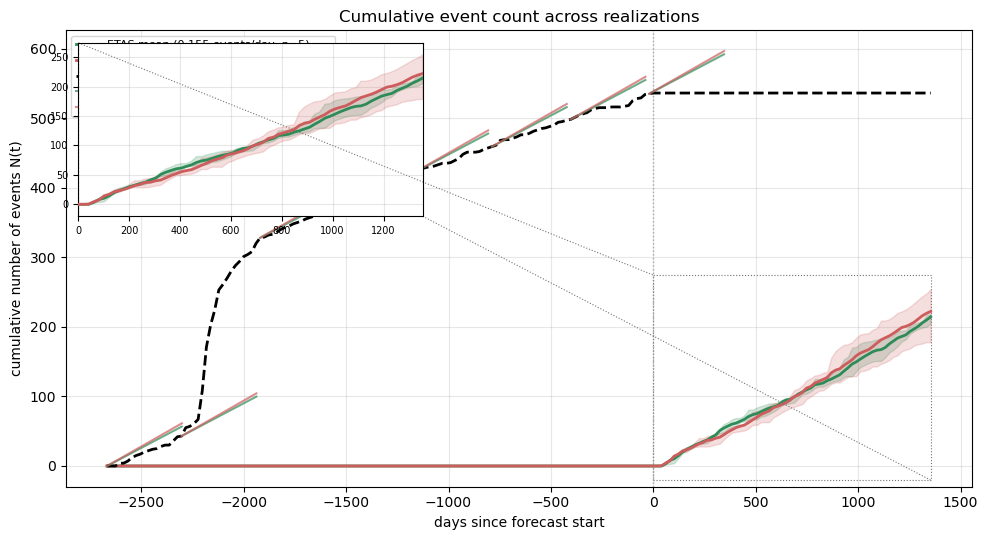

In [ ]:
# --- cumulative N(t): mean with 25–75% band ---
etas_mean = etas_curves.mean(axis=0)
thin_mean = thin_curves.mean(axis=0)
forecast_mask = t_grid >= 0.0
etas_slope = float(np.polyfit(t_grid[forecast_mask], etas_mean[forecast_mask], 1)[0])
thin_slope = float(np.polyfit(t_grid[forecast_mask], thin_mean[forecast_mask], 1)[0])

cum_ylim_curves = [etas_mean, thin_mean]
if etas_curves.shape[0] > 1:
    q25e, q75e = np.quantile(etas_curves, [0.25, 0.75], axis=0)
    q25t, q75t = np.quantile(thin_curves, [0.25, 0.75], axis=0)
    cum_ylim_curves.extend([q25e, q75e, q25t, q75t])
cum_test_ylims = ylim_in_xrange(t_grid, cum_ylim_curves, 0.0, forecast_days)

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_cumulative_event_count(
    ax,
    t_grid=t_grid,
    etas_curves=etas_curves,
    thin_curves=thin_curves,
    etas_slope=etas_slope,
    thin_slope=thin_slope,
    train_dt_days=train_dt_days,
    train_days=train_days,
    show_training_slopes=True,
    show_legend=True,
)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("cumulative number of events N(t)")
ax.set_title("Cumulative event count across realizations")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
add_test_window_inset(
    ax,
    forecast_days,
    lambda axins: draw_cumulative_event_count(
        axins,
        t_grid=t_grid,
        etas_curves=etas_curves,
        thin_curves=thin_curves,
        etas_slope=etas_slope,
        thin_slope=thin_slope,
        train_dt_days=train_dt_days,
        train_days=train_days,
        show_training_slopes=False,
        show_legend=False,
    ),
    ylims=cum_test_ylims,
)
fig.tight_layout()
show_fig(fig)


#### Event rate by time bin


/tmp/ipykernel_163512/2154760292.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


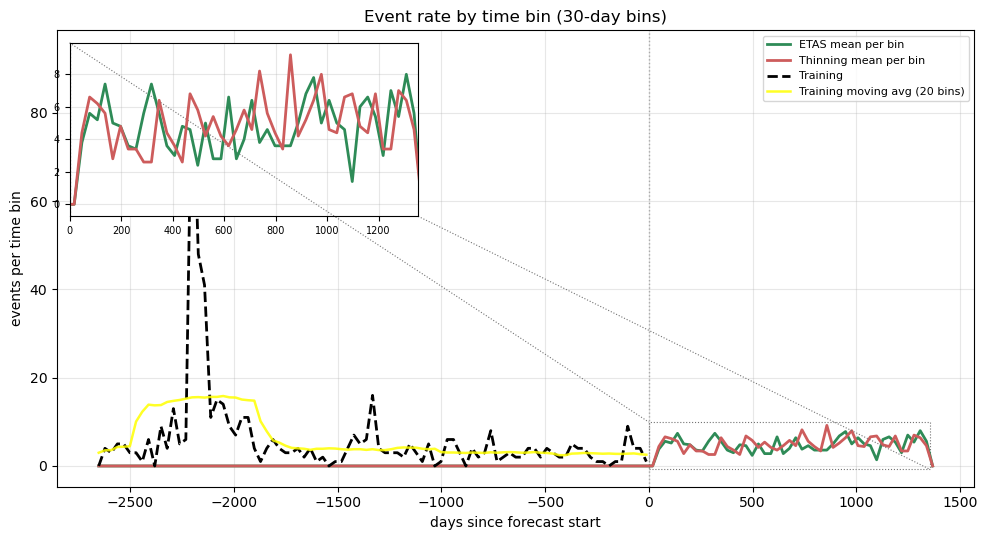

In [ ]:
# --- events per time bin (not cumulative) ---
BIN_LENGTH_DAYS = 30.0
t_min, t_max = -train_days, forecast_days
n_bins = int(np.ceil((t_max - t_min) / BIN_LENGTH_DAYS))
bin_edges = t_min + np.arange(n_bins + 1, dtype=float) * BIN_LENGTH_DAYS
if bin_edges[-1] < t_max:
    bin_edges = np.append(bin_edges, t_max)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
etas_bin_curves = np.vstack([
    events_per_time_bin(etas_by_seed[s]["dt_days"].to_numpy(), bin_edges)
    for s in selected_seeds
])
thin_bin_curves = np.vstack([
    events_per_time_bin(thinning_by_seed[s]["dt_days"].to_numpy(), bin_edges)
    for s in selected_seeds
])

etas_bin_mean = etas_bin_curves.mean(axis=0)
thin_bin_mean = thin_bin_curves.mean(axis=0)
bin_test_ylims = ylim_in_xrange(
    bin_centers,
    [etas_bin_mean, thin_bin_mean],
    0.0,
    forecast_days,
)

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_event_rate_by_bin(
    ax,
    bin_centers=bin_centers,
    bin_edges=bin_edges,
    etas_bin_curves=etas_bin_curves,
    thin_bin_curves=thin_bin_curves,
    train_dt_days=train_dt_days,
    bin_length_days=BIN_LENGTH_DAYS,
    include_training=True,
    show_legend=True,
)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("events per time bin")
ax.set_title(f"Event rate by time bin ({BIN_LENGTH_DAYS:g}-day bins)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
add_test_window_inset(
    ax,
    forecast_days,
    lambda axins: draw_event_rate_by_bin(
        axins,
        bin_centers=bin_centers,
        bin_edges=bin_edges,
        etas_bin_curves=etas_bin_curves,
        thin_bin_curves=thin_bin_curves,
        train_dt_days=train_dt_days,
        bin_length_days=BIN_LENGTH_DAYS,
        include_training=False,
        show_legend=False,
    ),
    ylims=bin_test_ylims,
)
fig.tight_layout()
show_fig(fig)


#### ETAS vs thinning agreement (tables)


In [ ]:
# --- ETAS vs thinning agreement across seeds ---
mean_nt_diff = np.abs(etas_curves.mean(axis=0) - thin_curves.mean(axis=0))
mean_bin_diff = np.abs(etas_bin_curves.mean(axis=0) - thin_bin_curves.mean(axis=0))
agreement_summary = pd.DataFrame({
    "metric": [
        "max |mean ETAS − mean thinning| on N(t) grid",
        "mean |mean ETAS − mean thinning| on N(t) grid",
        "max |mean ETAS − mean thinning| per bin",
        "mean |mean ETAS − mean thinning| per bin",
    ],
    "value": [
        float(mean_nt_diff.max()),
        float(mean_nt_diff.mean()),
        float(mean_bin_diff.max()),
        float(mean_bin_diff.mean()),
    ],
})
display(Markdown("**ETAS vs thinning agreement (across loaded seeds):**"))
display(agreement_summary)


**ETAS vs thinning agreement (across loaded seeds):**

,metric,value
0,max |mean ETAS − mean thinning| on N(t) grid,14.000000
1,mean |mean ETAS − mean thinning| on N(t) grid,1.955000
2,max |mean ETAS − mean thinning| per bin,5.600000
3,mean |mean ETAS − mean thinning| per bin,0.588148


#### Mean cumulative / rate-per-bin differences


/tmp/ipykernel_163512/3228636241.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


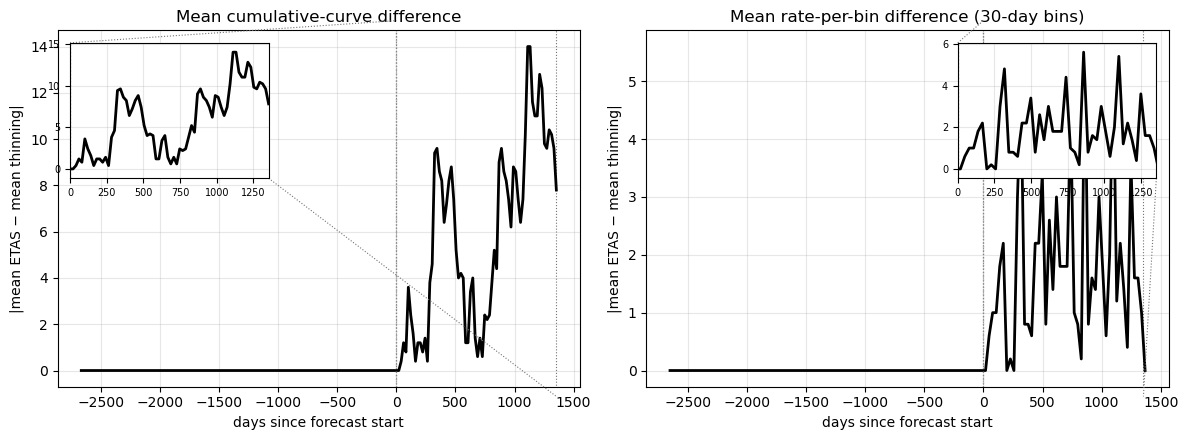

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(t_grid, mean_nt_diff, color="black", lw=2.0)
axes[0].axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7)
axes[0].set_xlabel("days since forecast start")
axes[0].set_ylabel("|mean ETAS − mean thinning|")
axes[0].set_title("Mean cumulative-curve difference")
axes[0].grid(True, alpha=0.3)
add_test_window_inset(
    axes[0],
    forecast_days,
    lambda axins: (
        axins.plot(t_grid, mean_nt_diff, color="black", lw=2.0),
        axins.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7),
    ),
    ylims=ylim_in_xrange(t_grid, [mean_nt_diff], 0.0, forecast_days),
)

axes[1].plot(bin_centers, mean_bin_diff, color="black", lw=2.0)
axes[1].axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7)
axes[1].set_xlabel("days since forecast start")
axes[1].set_ylabel("|mean ETAS − mean thinning|")
axes[1].set_title(f"Mean rate-per-bin difference ({BIN_LENGTH_DAYS:g}-day bins)")
axes[1].grid(True, alpha=0.3)
add_test_window_inset(
    axes[1],
    forecast_days,
    lambda axins: (
        axins.plot(bin_centers, mean_bin_diff, color="black", lw=2.0),
        axins.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7),
    ),
    loc="upper right",
    ylims=ylim_in_xrange(bin_centers, [mean_bin_diff], 0.0, forecast_days),
)
fig.tight_layout()
show_fig(fig)


#### Tier 1 — scalar summary tables


In [ ]:
# --- Tier 1: scalar summaries (metrics_df is computed on disk or in memory) ---
metrics_df = metrics_df.copy()
metrics_df["etas_median_iet_days"] = [
    median_interevent_days(catalogs_by_seed[int(seed)]["etas"]) for seed in metrics_df["seed"]
]
metrics_df["thinning_median_iet_days"] = [
    median_interevent_days(catalogs_by_seed[int(seed)]["thinning"]) for seed in metrics_df["seed"]
]
metrics_df["delta_n"] = metrics_df["thinning_n_events"] - metrics_df["etas_n_events"]
metrics_df["rel_delta_n"] = metrics_df["delta_n"] / metrics_df["etas_n_events"].replace(0, np.nan)
metrics_df["etas_bg_frac"] = metrics_df["etas_background"] / metrics_df["etas_n_events"].replace(0, np.nan)
metrics_df["thin_bg_frac"] = metrics_df["thinning_background"] / metrics_df["thinning_n_events"].replace(0, np.nan)

tier1_summary = pd.DataFrame({
    "metric": [
        "median thinning/ETAS ratio",
        "median |relative count error|",
        "median |Δ median interevent time| [days]",
        "median |Δ max magnitude|",
    ],
    "value": [
        float(metrics_df["thinning_over_etas_ratio"].median()),
        float(metrics_df["rel_delta_n"].abs().median()),
        float((metrics_df["thinning_median_iet_days"] - metrics_df["etas_median_iet_days"]).abs().median()),
        float((metrics_df["thinning_max_magnitude"] - metrics_df["etas_max_magnitude"]).abs().median()),
    ],
})
display(Markdown("**Tier 1 — ensemble scalar summary:**"))
display(tier1_summary)
display(metrics_df)


**Tier 1 — ensemble scalar summary:**

,metric,value
0,median thinning/ETAS ratio,1.060606
1,median |relative count error|,0.135922
2,median |Δ median interevent time| [days],0.122748
3,median |Δ max magnitude|,0.292969


,seed,etas_n_events,thinning_n_events,etas_background,thinning_background,etas_triggered,thinning_triggered,etas_median_dt_days,thinning_median_dt_days,etas_max_magnitude,thinning_max_magnitude,thinning_over_etas_ratio,etas_median_iet_days,thinning_median_iet_days,delta_n,rel_delta_n,etas_bg_frac,thin_bg_frac
0,0,206,178,62,48,144,130,631.431461,730.540265,5.776988,5.339838,0.864078,3.269134,3.146386,-28,-0.135922,0.300971,0.269663
1,1,218,249,59,66,159,183,779.480252,761.089151,6.119765,6.382076,1.142202,2.681014,2.565951,31,0.142202,0.270642,0.265060
2,2,165,175,59,63,106,112,622.312277,715.156727,5.297896,5.590866,1.060606,4.281065,4.281014,10,0.060606,0.357576,0.360000
3,3,205,255,62,79,143,176,706.558255,818.550513,5.762414,5.802593,1.243902,2.912414,2.715412,50,0.243902,0.302439,0.309804
4,4,278,254,65,73,213,181,883.954738,731.066623,6.158358,6.783679,0.913669,2.110102,2.529681,-24,-0.086331,0.233813,0.287402


#### Tier 1 — boxplot comparisons


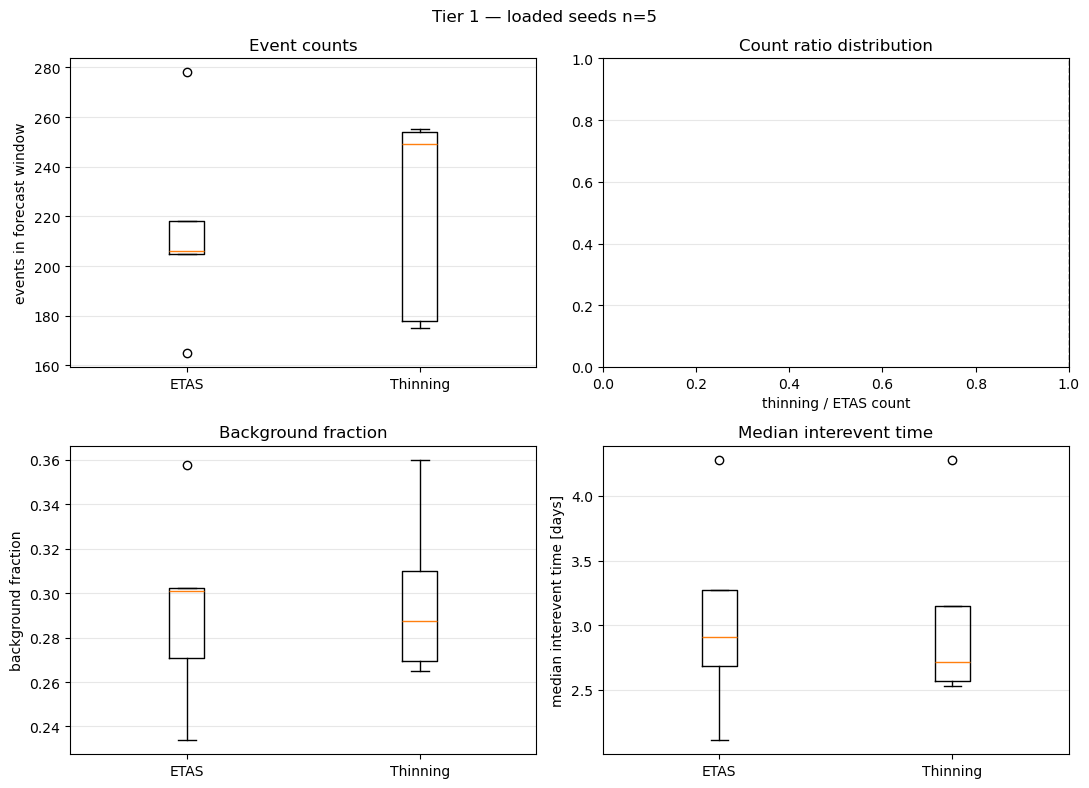

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].boxplot(
    [metrics_df["etas_n_events"], metrics_df["thinning_n_events"]],
    tick_labels=["ETAS", "Thinning"],
)
axes[0, 0].set_ylabel("events in forecast window")
axes[0, 0].set_title("Event counts")
axes[0, 0].grid(True, alpha=0.3, axis="y")

# Removed subplot at axes[0, 1] (thinning_over_etas_ratio histogram) as requested.
axes[0, 1].axvline(1.0, color="black", ls="--", lw=1.0)
axes[0, 1].set_xlabel("thinning / ETAS count")
axes[0, 1].set_title("Count ratio distribution")
axes[0, 1].grid(True, alpha=0.3, axis="y")

axes[1, 0].boxplot(
    [metrics_df["etas_bg_frac"].dropna(), metrics_df["thin_bg_frac"].dropna()],
    tick_labels=["ETAS", "Thinning"],
)
axes[1, 0].set_ylabel("background fraction")
axes[1, 0].set_title("Background fraction")
axes[1, 0].grid(True, alpha=0.3, axis="y")

axes[1, 1].boxplot(
    [metrics_df["etas_median_iet_days"], metrics_df["thinning_median_iet_days"]],
    tick_labels=["ETAS", "Thinning"],
)
axes[1, 1].set_ylabel("median interevent time [days]")
axes[1, 1].set_title("Median interevent time")
axes[1, 1].grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Tier 1 — loaded seeds n={len(selected_seeds)}", fontsize=12)
fig.tight_layout()
show_fig(fig)


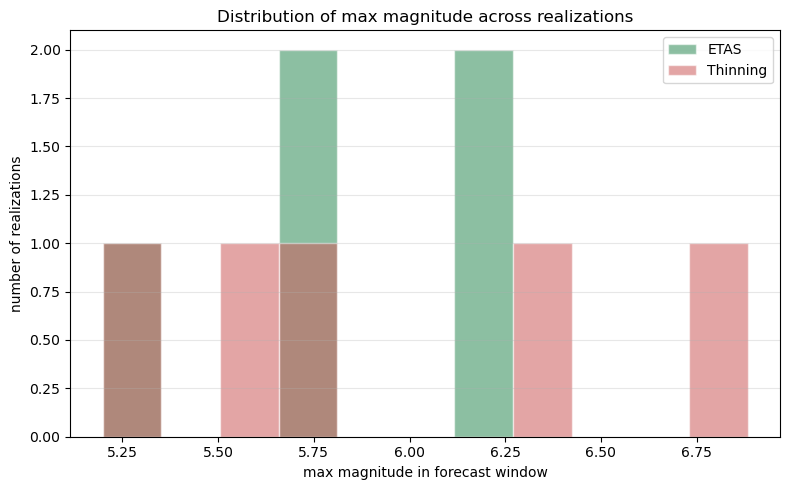

In [ ]:
# Max magnitude distribution across realizations (Tier 1)
m_lo = min(metrics_df["etas_max_magnitude"].min(), metrics_df["thinning_max_magnitude"].min()) - 0.1
m_hi = max(metrics_df["etas_max_magnitude"].max(), metrics_df["thinning_max_magnitude"].max()) + 0.1
mag_bins = np.linspace(m_lo, m_hi, 12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    metrics_df["etas_max_magnitude"],
    bins=mag_bins,
    alpha=0.55,
    color=ETAS_COLOR,
    label="ETAS",
    edgecolor="white",
)
ax.hist(
    metrics_df["thinning_max_magnitude"],
    bins=mag_bins,
    alpha=0.55,
    color=THINNING_COLOR,
    label="Thinning",
    edgecolor="white",
)
ax.set_xlabel("max magnitude in forecast window")
ax.set_ylabel("number of realizations")
ax.set_title("Distribution of max magnitude across realizations")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
show_fig(fig)


### Tier 2 — distributional comparisons

Pooled across all loaded realizations: interevent-time PDFs, nearest-neighbor distances, and distance to triggering parent (ETAS: stored parent coordinates; thinning: dominant parent at event time).

2026-07-07 23:00:25,986 - INFO - Loading Calculation...
2026-07-07 23:00:25,991 - INFO -   model is named NoName ETAS Model, has ID fde4667b33a3b02a
2026-07-07 23:00:25,992 - INFO -   Time Window: 
      1981-01-01 00:00:00 (aux start)
      2009-02-03 00:00:00 (start)
      2016-05-23 23:05:46 (end).
2026-07-07 23:00:25,992 - INFO -   free_productivity: False, free_background: False
2026-07-07 23:00:26,185 - INFO -   202664 out of 266662 events are within time window.
2026-07-07 23:00:26,186 - INFO -   Coordinates of region: [array([  30.8615, -122.215 ]), array([  30.8615, -113.995 ]), array([  38.541, -113.995]), array([  38.541, -122.215]), array([  30.8615, -122.215 ])]
2026-07-07 23:00:26,467 - INFO - Region has 640397.3942796533 square km
2026-07-07 23:00:26,468 - INFO - 202664 events lie within target region.
2026-07-07 23:00:26,473 - DEBUG -   Checking for rounding issues...
2026-07-07 23:00:26,475 - DEBUG -   No rounding issues found.
2026-07-07 23:00:26,477 - INFO - 2135 eve

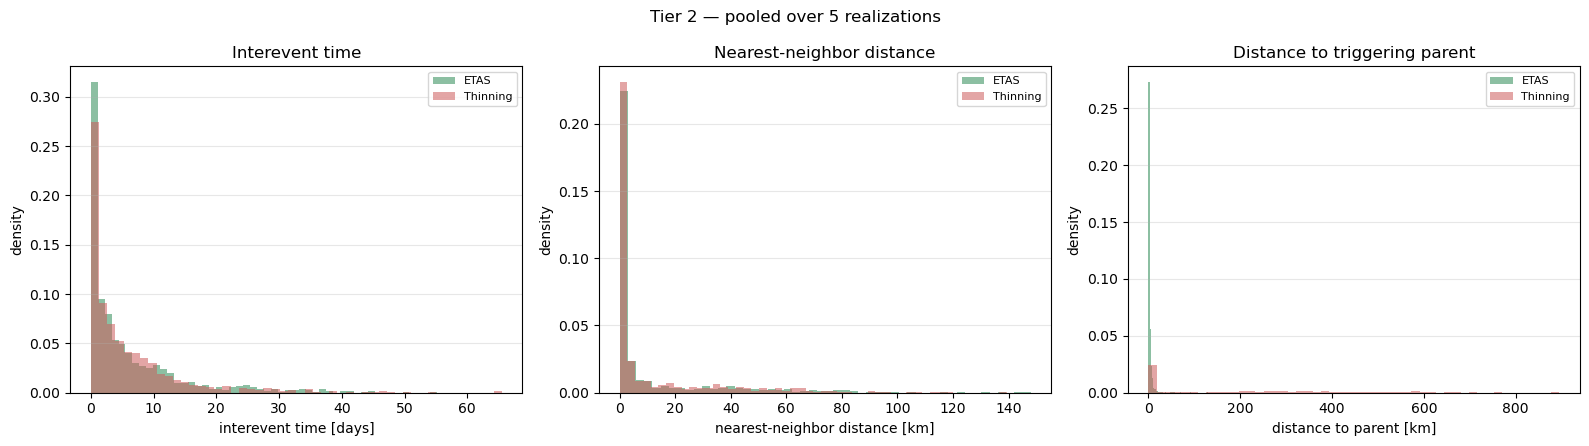

In [ ]:
etas_iet, thin_iet = [], []
etas_nn, thin_nn = [], []
etas_parent, thin_parent = [], []

intensity_ctx = load_intensity_context(ensemble_dir, meta, selected_seeds[0])
# Dominant-parent distance for thinning is expensive (A_h per prior event); use a small subset.
thin_parent_seeds = selected_seeds[: min(3, len(selected_seeds))]
if len(thin_parent_seeds) < len(selected_seeds):
    print(f"Thinning parent distances: using seeds {thin_parent_seeds} (subset for speed).")

for seed in selected_seeds:
    etas_cat = etas_by_seed[seed]
    thin_cat = thinning_by_seed[seed]
    etas_iet.append(interevent_times(etas_cat["dt_days"].to_numpy()))
    thin_iet.append(interevent_times(thin_cat["dt_days"].to_numpy()))
    etas_nn.append(nearest_neighbor_distances_km(etas_cat))
    thin_nn.append(nearest_neighbor_distances_km(thin_cat))
    etas_parent.append(etas_parent_distances_km(etas_cat))
    if seed in thin_parent_seeds:
        ctx_seed = {**intensity_ctx, "hist_events": list(intensity_ctx["hist_events"])}
        thin_parent.append(thinning_dominant_parent_distances_km(thin_cat, ctx_seed))

etas_iet_all = np.concatenate(etas_iet) if etas_iet else np.array([])
thin_iet_all = np.concatenate(thin_iet) if thin_iet else np.array([])
etas_nn_all = np.concatenate(etas_nn) if etas_nn else np.array([])
thin_nn_all = np.concatenate(thin_nn) if thin_nn else np.array([])
etas_parent_all = np.concatenate(etas_parent) if etas_parent else np.array([])
thin_parent_all = np.concatenate(thin_parent) if thin_parent else np.array([])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, etas_data, thin_data, xlabel, title in [
    (axes[0], etas_iet_all, thin_iet_all, "interevent time [days]", "Interevent time"),
    (axes[1], etas_nn_all, thin_nn_all, "nearest-neighbor distance [km]", "Nearest-neighbor distance"),
    (axes[2], etas_parent_all, thin_parent_all, "distance to parent [km]", "Distance to triggering parent"),
]:
    if etas_data.size:
        ax.hist(etas_data, bins=50, density=True, alpha=0.55, color=ETAS_COLOR, label="ETAS")
    if thin_data.size:
        ax.hist(thin_data, bins=50, density=True, alpha=0.55, color=THINNING_COLOR, label="Thinning")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Tier 2 — pooled over {len(selected_seeds)} realizations", fontsize=12)
fig.tight_layout()
show_fig(fig)


#### Tier 2 — KS test tables


In [ ]:
tier2_ks = []
for name, etas_data, thin_data in [
    ("interevent time", etas_iet_all, thin_iet_all),
    ("nearest-neighbor distance", etas_nn_all, thin_nn_all),
    ("parent distance", etas_parent_all, thin_parent_all),
]:
    if etas_data.size and thin_data.size:
        stat, pval = stats.ks_2samp(etas_data, thin_data)
        tier2_ks.append({"comparison": name, "KS statistic": stat, "p-value": pval})
if tier2_ks:
    display(Markdown("**Tier 2 — pooled KS tests (ETAS vs thinning):**"))
    display(pd.DataFrame(tier2_ks))


**Tier 2 — pooled KS tests (ETAS vs thinning):**

,comparison,KS statistic,p-value
0,interevent time,0.030547,6.749191e-01
1,nearest-neighbor distance,0.071037,7.582322e-03
2,parent distance,0.564706,5.308230e-81


### Tier 3 — mechanistic checks

Conditional space-integrated intensity λ(t) (history baseline + each method's full catalog) and rate consistency: ∫λ(t)dt versus observed event count. Uses inversion parameters for the loaded ensemble.

#### Tier 3 — λ(t) intensity


2026-07-07 23:02:26,621 - DEBUG - vmin 0.050428969395949264 vmax 1.5258647163082926
2026-07-07 23:02:26,622 - DEBUG - ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])
2026-07-07 23:02:26,628 - DEBUG - vmin 0.050428969395949264 vmax 1.5258647163082926
2026-07-07 23:02:26,628 - DEBUG - ticklocs array([2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02])
2026-07-07 23:02:26,629 - DEBUG - vmin 0.050428969395949264 vmax 1.5258647163082926
2026-07-07 23:02:26,629 - DEBUG - ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])
2026-07-07 23:02:26,649 - DEBUG - vmin 0.050428969395949264 vmax 1.5258647163082

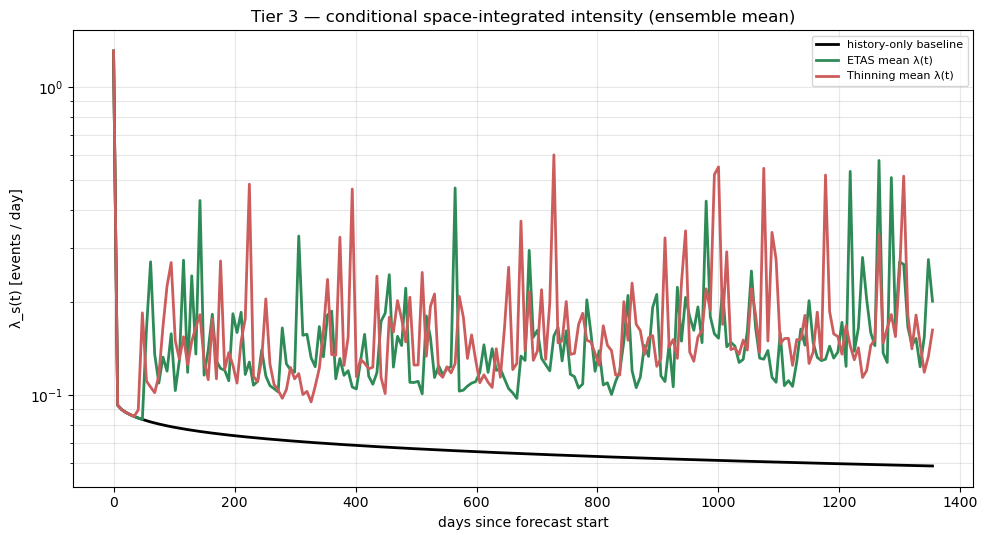

In [ ]:
if "intensity_ctx" not in globals():
    intensity_ctx = load_intensity_context(ensemble_dir, meta, selected_seeds[0])

ctx = intensity_ctx
cat_cmp = ctx["module"]
t_abs_grid = np.linspace(ctx["forecast_start_t"], ctx["forecast_end_t"], 200)
dt_grid = t_abs_grid - ctx["forecast_start_t"]
lam_hist = np.array([
    cat_cmp.lambda_s_total(t, ctx["hist_events"], ctx["polygon"], ctx["theta_0"], ctx["a_h_resolution"])
    for t in t_abs_grid
])

# λ(t) is expensive; evaluate on a small seed subset for the ensemble-mean curves.
lambda_seeds = selected_seeds[: min(5, len(selected_seeds))]
if len(lambda_seeds) < len(selected_seeds):
    print(f"λ(t) plots: using seeds {lambda_seeds} (subset for speed).")

lam_etas_seeds, lam_thin_seeds = [], []
rate_rows = []
for seed in lambda_seeds:
    etas_cat = etas_by_seed[seed]
    thin_cat = thinning_by_seed[seed]
    lam_e = lambda_on_grid(etas_cat, ctx, t_abs_grid)
    lam_t = lambda_on_grid(thin_cat, ctx, t_abs_grid)
    lam_etas_seeds.append(lam_e)
    lam_thin_seeds.append(lam_t)
    int_e = integrated_lambda(lam_e, t_abs_grid)
    int_t = integrated_lambda(lam_t, t_abs_grid)
    rate_rows.append({
        "seed": seed,
        "etas_n": len(etas_cat),
        "thin_n": len(thin_cat),
        "etas_trapz_lambda": int_e,
        "thin_trapz_lambda": int_t,
        "etas_n_over_trapz": len(etas_cat) / int_e if int_e > 0 else np.nan,
        "thin_n_over_trapz": len(thin_cat) / int_t if int_t > 0 else np.nan,
    })

lam_etas_mean = np.mean(lam_etas_seeds, axis=0)
lam_thin_mean = np.mean(lam_thin_seeds, axis=0)
rate_consistency_df = pd.DataFrame(rate_rows)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(dt_grid, lam_hist, color="black", lw=2.0, label="history-only baseline")
ax.plot(dt_grid, lam_etas_mean, color=ETAS_COLOR, lw=2.0, label="ETAS mean λ(t)")
ax.plot(dt_grid, lam_thin_mean, color=THINNING_COLOR, lw=2.0, label="Thinning mean λ(t)")
ax.set_yscale("log")
ax.set_xlabel("days since forecast start")
ax.set_ylabel("λ_s(t) [events / day]")
ax.set_title("Tier 3 — conditional space-integrated intensity (ensemble mean)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
show_fig(fig)


#### Tier 3 — rate-consistency tables


In [ ]:

display(Markdown("**Tier 3 — spatial integral / rate consistency (per seed):**"))
display(rate_consistency_df.describe().T[["mean", "50%", "std"]].rename(columns={"50%": "median"}))


**Tier 3 — spatial integral / rate consistency (per seed):**

,mean,median,std
seed,2.000000,2.000000,1.581139
etas_n,214.400000,206.000000,40.795833
thin_n,222.200000,249.000000,41.793540
etas_trapz_lambda,212.948957,202.598961,27.178799
thin_trapz_lambda,234.645275,239.189498,43.359833
etas_n_over_trapz,1.001361,1.016787,0.075896
thin_n_over_trapz,0.948843,0.974334,0.083333


#### Tier 3 — integrated λ vs observed N


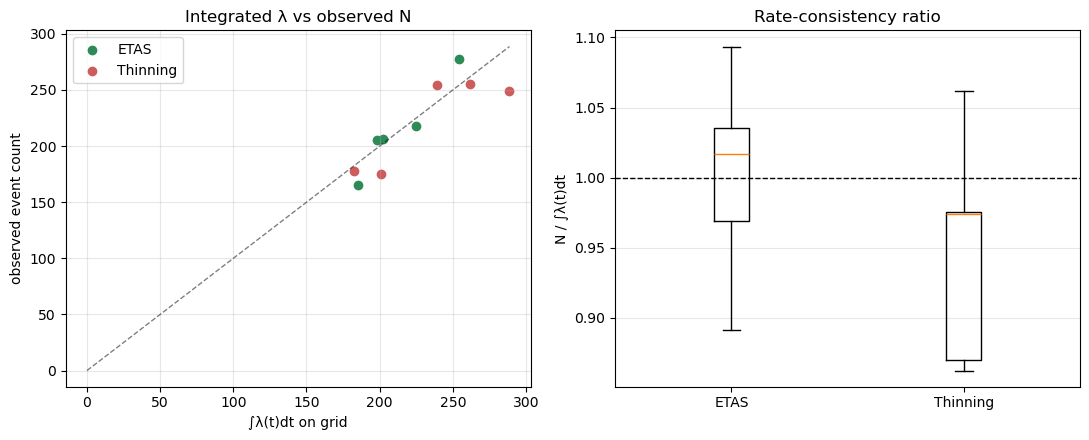

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(rate_consistency_df["etas_trapz_lambda"], rate_consistency_df["etas_n"], c=ETAS_COLOR, label="ETAS")
axes[0].scatter(rate_consistency_df["thin_trapz_lambda"], rate_consistency_df["thin_n"], c=THINNING_COLOR, label="Thinning")
mx = max(rate_consistency_df[["etas_trapz_lambda", "thin_trapz_lambda", "etas_n", "thin_n"]].max())
axes[0].plot([0, mx], [0, mx], "k--", lw=1.0, alpha=0.5)
axes[0].set_xlabel("∫λ(t)dt on grid")
axes[0].set_ylabel("observed event count")
axes[0].set_title("Integrated λ vs observed N")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(
    [rate_consistency_df["etas_n_over_trapz"].dropna(), rate_consistency_df["thin_n_over_trapz"].dropna()],
    tick_labels=["ETAS", "Thinning"],
)
axes[1].axhline(1.0, color="black", ls="--", lw=1.0)
axes[1].set_ylabel("N / ∫λ(t)dt")
axes[1].set_title("Rate-consistency ratio")
axes[1].grid(True, alpha=0.3, axis="y")
fig.tight_layout()
show_fig(fig)


### Formal statistical tests

Paired tests respect the shared random seed per realization. Pooled KS tests concatenate all loaded events (unpaired). Permutation test shuffles method labels on paired count differences.

In [ ]:
if "intensity_ctx" not in globals():
    intensity_ctx = load_intensity_context(ensemble_dir, meta, selected_seeds[0])

etas_counts = metrics_df["etas_n_events"].to_numpy()
thin_counts = metrics_df["thinning_n_events"].to_numpy()
paired_diff = thin_counts - etas_counts

# Paired Wilcoxon signed-rank on event counts
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(thin_counts, etas_counts)

# Pearson correlation on paired counts
pearson_r, pearson_p = stats.pearsonr(etas_counts, thin_counts)

# Pooled KS on interevent times and magnitudes
etas_iet_pool = np.concatenate([
    interevent_times(etas_by_seed[s]["dt_days"].to_numpy(dtype=float)) for s in selected_seeds
])
thin_iet_pool = np.concatenate([
    interevent_times(thinning_by_seed[s]["dt_days"].to_numpy(dtype=float)) for s in selected_seeds
])
etas_iet_pool = etas_iet_pool[np.isfinite(etas_iet_pool)]
thin_iet_pool = thin_iet_pool[np.isfinite(thin_iet_pool)]

mc_val = float(intensity_ctx["mc"]) if "intensity_ctx" in globals() else np.nan
etas_m_pool = np.concatenate([etas_by_seed[s]["m"].to_numpy(dtype=float) for s in selected_seeds])
thin_m_pool = np.concatenate([thinning_by_seed[s]["m"].to_numpy(dtype=float) for s in selected_seeds])
if np.isfinite(mc_val):
    etas_m_pool = etas_m_pool[etas_m_pool >= mc_val]
    thin_m_pool = thin_m_pool[thin_m_pool >= mc_val]

ks_iet_stat, ks_iet_p = stats.ks_2samp(etas_iet_pool, thin_iet_pool)
ks_m_stat, ks_m_p = stats.ks_2samp(etas_m_pool, thin_m_pool)

# Per-seed KS on interevent times (summarize p-values)
per_seed_ks_iet = []
for seed in selected_seeds:
    e = interevent_times(etas_by_seed[seed]["dt_days"].to_numpy(dtype=float))
    t = interevent_times(thinning_by_seed[seed]["dt_days"].to_numpy(dtype=float))
    e, t = e[np.isfinite(e)], t[np.isfinite(t)]
    if e.size and t.size:
        stat, pval = stats.ks_2samp(e, t)
        per_seed_ks_iet.append({"seed": seed, "KS interevent time": stat, "p-value": pval})

# Permutation test on mean paired count difference
n_perm = 5000
rng = np.random.default_rng(0)
obs_mean_diff = paired_diff.mean()
perm_diffs = np.empty(n_perm)
for i in range(n_perm):
    signs = rng.choice([-1.0, 1.0], size=len(paired_diff))
    perm_diffs[i] = (signs * paired_diff).mean()
perm_p = float((np.abs(perm_diffs) >= abs(obs_mean_diff)).mean())

formal_results = pd.DataFrame([
    {"test": "Paired Wilcoxon (counts)", "statistic": wilcoxon_stat, "p-value": wilcoxon_p},
    {"test": "Pearson r (counts)", "statistic": pearson_r, "p-value": pearson_p},
    {"test": "KS pooled interevent time", "statistic": ks_iet_stat, "p-value": ks_iet_p},
    {"test": "KS pooled magnitude (≥ mc)", "statistic": ks_m_stat, "p-value": ks_m_p},
    {"test": "Permutation mean Δcount", "statistic": obs_mean_diff, "p-value": perm_p},
])
display(Markdown("**Formal tests:**"))
display(formal_results)

if per_seed_ks_iet:
    per_seed_ks_df = pd.DataFrame(per_seed_ks_iet)
    display(Markdown(
        f"**Per-seed KS on interevent time:** median p = {per_seed_ks_df['p-value'].median():.4f}, "
        f"fraction p>0.05 = {(per_seed_ks_df['p-value'] > 0.05).mean():.2%}"
    ))
    display(per_seed_ks_df.head(10))


**Formal tests:**

,test,statistic,p-value
0,Paired Wilcoxon (counts),5.000000,0.625000
1,Pearson r (counts),0.661817,0.223718
2,KS pooled interevent time,0.030547,0.674919
3,KS pooled magnitude (≥ mc),0.043799,0.236452
4,Permutation mean Δcount,7.800000,0.618800


**Per-seed KS on interevent time:** median p = 0.8398, fraction p>0.05 = 100.00%

,seed,KS interevent time,p-value
0,0,0.050517,0.954445
1,1,0.055876,0.839789
2,2,0.058102,0.915332
3,3,0.057395,0.822414
4,4,0.094904,0.169685


In [ ]:
import csep
from csep.core.catalogs import CSEPCatalog
from csep.core.forecasts import CatalogForecast
from csep.core.regions import california_relm_region, create_space_magnitude_region
from csep.utils.constants import CSEP_MW_BINS
from csep.utils.time_utils import datetime_to_utc_epoch


## CSEP expected rates from catalog forecasts

Treat each loaded realization as one synthetic catalog, wrap them in a `CatalogForecast`, and call `get_expected_rates()`:

1. Define a space–magnitude region (California RELM grid + CSEP magnitude bins).
2. Convert each pandas catalog to `CSEPCatalog`.
3. Bin every realization with `spatial_magnitude_counts()`, sum across realizations, divide by `n_cat`.

This mirrors `examples/tutorials/working_with_catalog_forecasts.py` in PyCSEP.

In [ ]:
def _parse_forecast_window(meta: dict) -> tuple | None:
    """Return (start, end) if meta has both window endpoints, else None."""
    if not meta.get("timewindow_end") or not meta.get("testwindow_end"):
        return None
    start = pd.to_datetime(meta["timewindow_end"], utc=True).to_pydatetime()
    end = pd.to_datetime(meta["testwindow_end"], utc=True).to_pydatetime()
    return start, end


def forecast_window_from_meta(
    meta: dict,
    *,
    ensemble_dir: Path,
    seed: int,
    catalogs_by_seed: dict[int, dict[str, pd.DataFrame]],
) -> tuple:
    """Forecast interval: timewindow_end → testwindow_end (UTC-aware datetimes)."""
    window = _parse_forecast_window(meta)
    if window is not None:
        return window

    realization_meta_path = _realization_dir_for_seed(ensemble_dir, seed) / "realization_meta.json"
    if realization_meta_path.is_file():
        realization_meta = json.loads(realization_meta_path.read_text(encoding="utf-8"))
        window = _parse_forecast_window(realization_meta)
        if window is not None:
            print(f"Forecast window from {realization_meta_path.name} (seed={seed})")
            return window

    all_times = []
    for catalogs in catalogs_by_seed.values():
        for df in catalogs.values():
            if df.empty:
                continue
            if "time" in df.columns:
                all_times.append(pd.to_datetime(df["time"], utc=True))
            elif "t" in df.columns:
                all_times.append(
                    pd.Timestamp("1970-01-01", tz="UTC")
                    + pd.to_timedelta(df["t"], unit="D")
                )
    if all_times:
        times = pd.concat(all_times, ignore_index=True)
        print("Forecast window inferred from min/max event times in loaded catalogs")
        return times.min().to_pydatetime(), times.max().to_pydatetime()

    raise ValueError(
        "Could not determine forecast window: missing ensemble_meta.json, "
        "realization_meta.json, and catalog time columns."
    )


def _catalog_origin_time_epoch(df: pd.DataFrame) -> pd.Series:
    """Absolute event times as CSEP UTC epochs (ms)."""
    if "time" in df.columns:
        return pd.to_datetime(df["time"], utc=True).map(datetime_to_utc_epoch)
    if "t" in df.columns:
        epochs = pd.Timestamp("1970-01-01", tz="UTC") + pd.to_timedelta(df["t"], unit="D")
        return epochs.map(datetime_to_utc_epoch)
    raise KeyError("catalog needs a 'time' or 't' column for CSEP conversion")


def _catalog_coordinate_series(df: pd.DataFrame, *, primary: str, fallback: str) -> pd.Series:
    if primary in df.columns:
        return df[primary].astype(float)
    if fallback in df.columns:
        return df[fallback].astype(float)
    raise KeyError(f"catalog needs '{primary}' or '{fallback}'")


def dataframe_to_csep_catalog(
    df: pd.DataFrame,
    *,
    catalog_id: int,
    region,
) -> CSEPCatalog:
    """Map ensemble CSV columns to the CSEP catalog dtype."""
    csep_df = pd.DataFrame(
        {
            "id": [f"evt_{i}" for i in range(len(df))],
            "origin_time": _catalog_origin_time_epoch(df),
            "latitude": _catalog_coordinate_series(df, primary="latitude", fallback="y"),
            "longitude": _catalog_coordinate_series(df, primary="longitude", fallback="x"),
            "depth": np.zeros(len(df)),
            "magnitude": _catalog_coordinate_series(df, primary="magnitude", fallback="m"),
            "catalog_id": catalog_id,
        }
    )
    return CSEPCatalog.from_dataframe(csep_df, region=region)


def build_catalog_forecast(
    catalogs_by_seed: dict[int, pd.DataFrame],
    *,
    name: str,
    region,
    start_time,
    end_time,
    filter_spatial: bool = True,
) -> CatalogForecast:
    """One CatalogForecast from the loaded seed → catalog mapping."""
    seeds = sorted(catalogs_by_seed)
    catalogs = [
        dataframe_to_csep_catalog(catalogs_by_seed[seed], catalog_id=i, region=region)
        for i, seed in enumerate(seeds)
    ]
    return CatalogForecast(
        catalogs=catalogs,
        region=region,
        name=name,
        start_time=start_time,
        end_time=end_time,
        n_cat=len(catalogs),
        filter_spatial=filter_spatial,
        apply_filters=filter_spatial,
    )


# California RELM spatial grid with standard CSEP magnitude bin edges.
csep_region = create_space_magnitude_region(california_relm_region(), CSEP_MW_BINS)
forecast_start, forecast_end = forecast_window_from_meta(
    meta,
    ensemble_dir=ensemble_dir,
    seed=selected_seeds[0],
    catalogs_by_seed=catalogs_by_seed,
)

print(
    f"CSEP region: {csep_region.name}, "
    f"{csep_region.num_nodes} spatial cells, {len(csep_region.magnitudes)} magnitude bins"
)
print(f"Forecast window: {forecast_start} → {forecast_end}")


CSEP region: relm-california, 7682 spatial cells, 76 magnitude bins
Forecast window: 2016-05-23 23:05:46+00:00 → 2020-01-01 00:00:00+00:00


In [ ]:
etas_catalog_forecast = build_catalog_forecast(
    etas_by_seed,
    name="ETAS ensemble",
    region=csep_region,
    start_time=forecast_start,
    end_time=forecast_end,
)
thin_catalog_forecast = build_catalog_forecast(
    thinning_by_seed,
    name="Thinning ensemble",
    region=csep_region,
    start_time=forecast_start,
    end_time=forecast_end,
)

etas_expected = etas_catalog_forecast.get_expected_rates(verbose=True)
thin_expected = thin_catalog_forecast.get_expected_rates(verbose=True)

etas_event_counts = etas_catalog_forecast.get_event_counts()
thin_event_counts = thin_catalog_forecast.get_event_counts()

summary = pd.DataFrame(
    {
        "method": ["ETAS", "Thinning"],
        "n_realizations": [etas_catalog_forecast.n_cat, thin_catalog_forecast.n_cat],
        "mean_events_per_catalog": [etas_event_counts.mean(), thin_event_counts.mean()],
        "mean_total_rate": [etas_expected.data.sum(), thin_expected.data.sum()],
    }
)
display(summary)
print(f"Expected-rate array shape (spatial × magnitude): {etas_expected.data.shape}")


Processed 1 catalogs in 0.001 seconds
Processed 2 catalogs in 0.002 seconds
Processed 3 catalogs in 0.003 seconds
Processed 4 catalogs in 0.004 seconds
Processed 5 catalogs in 0.004 seconds
Processed 1 catalogs in 0.002 seconds
Processed 2 catalogs in 0.003 seconds
Processed 3 catalogs in 0.004 seconds
Processed 4 catalogs in 0.005 seconds
Processed 5 catalogs in 0.005 seconds


,method,n_realizations,mean_events_per_catalog,mean_total_rate
0,ETAS,5,168.2,168.2
1,Thinning,5,177.4,177.4


Expected-rate array shape (spatial × magnitude): (7682, 76)


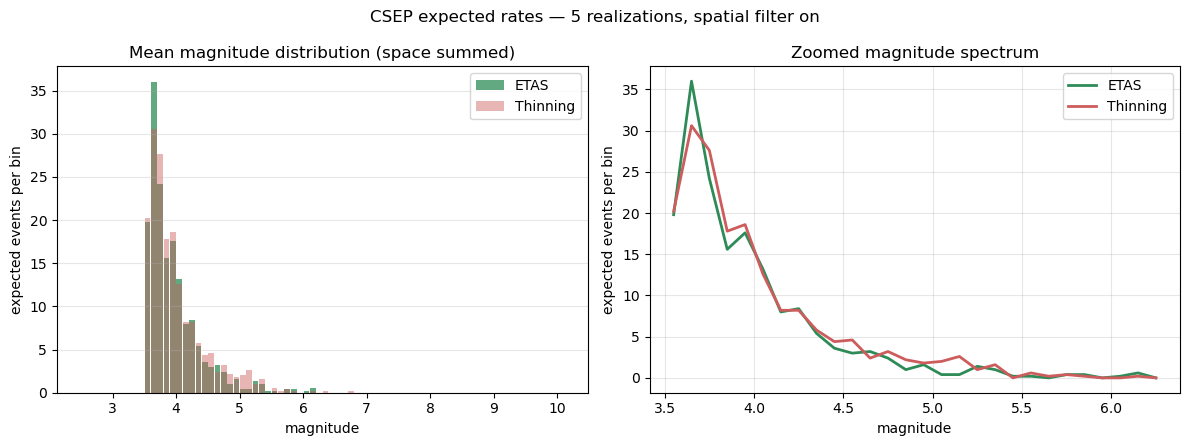

In [ ]:
mag_bins = np.asarray(etas_expected.magnitudes, dtype=float)
dmw = mag_bins[1] - mag_bins[0]
mag_centers = mag_bins + dmw / 2

etas_mag_counts = etas_expected.magnitude_counts()
thin_mag_counts = thin_expected.magnitude_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    mag_centers,
    etas_mag_counts,
    width=dmw * 0.9,
    color=ETAS_COLOR,
    alpha=0.75,
    label="ETAS",
)
axes[0].bar(
    mag_centers,
    thin_mag_counts,
    width=dmw * 0.9,
    color=THINNING_COLOR,
    alpha=0.45,
    label="Thinning",
)
axes[0].set_xlabel("magnitude")
axes[0].set_ylabel("expected events per bin")
axes[0].set_title("Mean magnitude distribution (space summed)")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

m_lo = max(2.5, float(min(etas_by_seed[s]["magnitude"].min() for s in selected_seeds)) - 0.1)
m_hi = min(8.5, float(max(etas_by_seed[s]["magnitude"].max() for s in selected_seeds)) + 0.1)
mask = (mag_centers >= m_lo) & (mag_centers <= m_hi)

axes[1].plot(mag_centers[mask], etas_mag_counts[mask], color=ETAS_COLOR, lw=2.0, label="ETAS")
axes[1].plot(mag_centers[mask], thin_mag_counts[mask], color=THINNING_COLOR, lw=2.0, label="Thinning")
axes[1].set_xlabel("magnitude")
axes[1].set_ylabel("expected events per bin")
axes[1].set_title("Zoomed magnitude spectrum")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    f"CSEP expected rates — {len(selected_seeds)} realizations, spatial filter on",
    fontsize=12,
)
fig.tight_layout()
show_fig(fig)


2026-07-07 23:02:29,019 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x71922b5beb10>
2026-07-07 23:02:29,027 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x719230142910>


/tmp/ipykernel_163512/2412352894.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


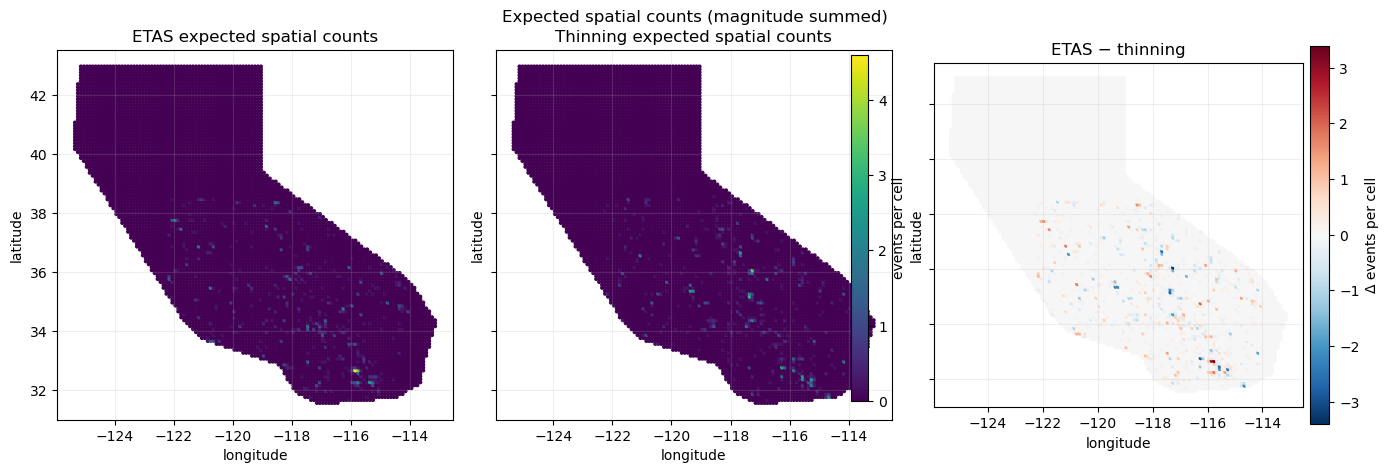

In [ ]:
# Spatially aggregated expected rate per cell (M>=min magnitude), ETAS vs thinning.
etas_spatial = etas_expected.spatial_counts()
thin_spatial = thin_expected.spatial_counts()
lons, lats = csep_region.midpoints().T

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)
vmax = max(etas_spatial.max(), thin_spatial.max())

sc0 = axes[0].scatter(lons, lats, c=etas_spatial, s=4, cmap="viridis", vmin=0, vmax=vmax)
axes[0].set_title("ETAS expected spatial counts")
axes[1].scatter(lons, lats, c=thin_spatial, s=4, cmap="viridis", vmin=0, vmax=vmax)
axes[1].set_title("Thinning expected spatial counts")

diff = etas_spatial - thin_spatial
vabs = np.max(np.abs(diff))
sc2 = axes[2].scatter(
    lons,
    lats,
    c=diff,
    s=4,
    cmap="RdBu_r",
    vmin=-vabs,
    vmax=vabs,
)
axes[2].set_title("ETAS − thinning")

for ax in axes:
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

fig.colorbar(sc0, ax=axes[:2], fraction=0.03, pad=0.02, label="events per cell")
fig.colorbar(sc2, ax=axes[2], fraction=0.05, pad=0.02, label="Δ events per cell")
fig.suptitle("Expected spatial counts (magnitude summed)", fontsize=12)
fig.tight_layout()
show_fig(fig)


## Spatial distribution for selected magnitude bin(s)

`expected_rates.data` has shape `(n_spatial, n_magnitude)`. Column `j` is the **expected event count per spatial cell** in magnitude bin `[m_j, m_j + Δm)`.

Summing column `j` over space recovers the marginal entry from `magnitude_counts()[j]` — the map below is the spatial **decomposition** of that marginal, not a different distribution.

M∈[4.0, 4.1): spatial sum ETAS=13.2000 (marginal=13.2000), thinning=12.6000 (marginal=12.6000)
M∈[5.0, 5.1): spatial sum ETAS=0.4000 (marginal=0.4000), thinning=2.0000 (marginal=2.0000)
M∈[6.0, 6.1): spatial sum ETAS=0.2000 (marginal=0.2000), thinning=0.0000 (marginal=0.0000)
2026-07-07 23:02:29,479 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x71922bd1f5d0>
2026-07-07 23:02:29,495 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x719218088bd0>


/tmp/ipykernel_163512/645454648.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


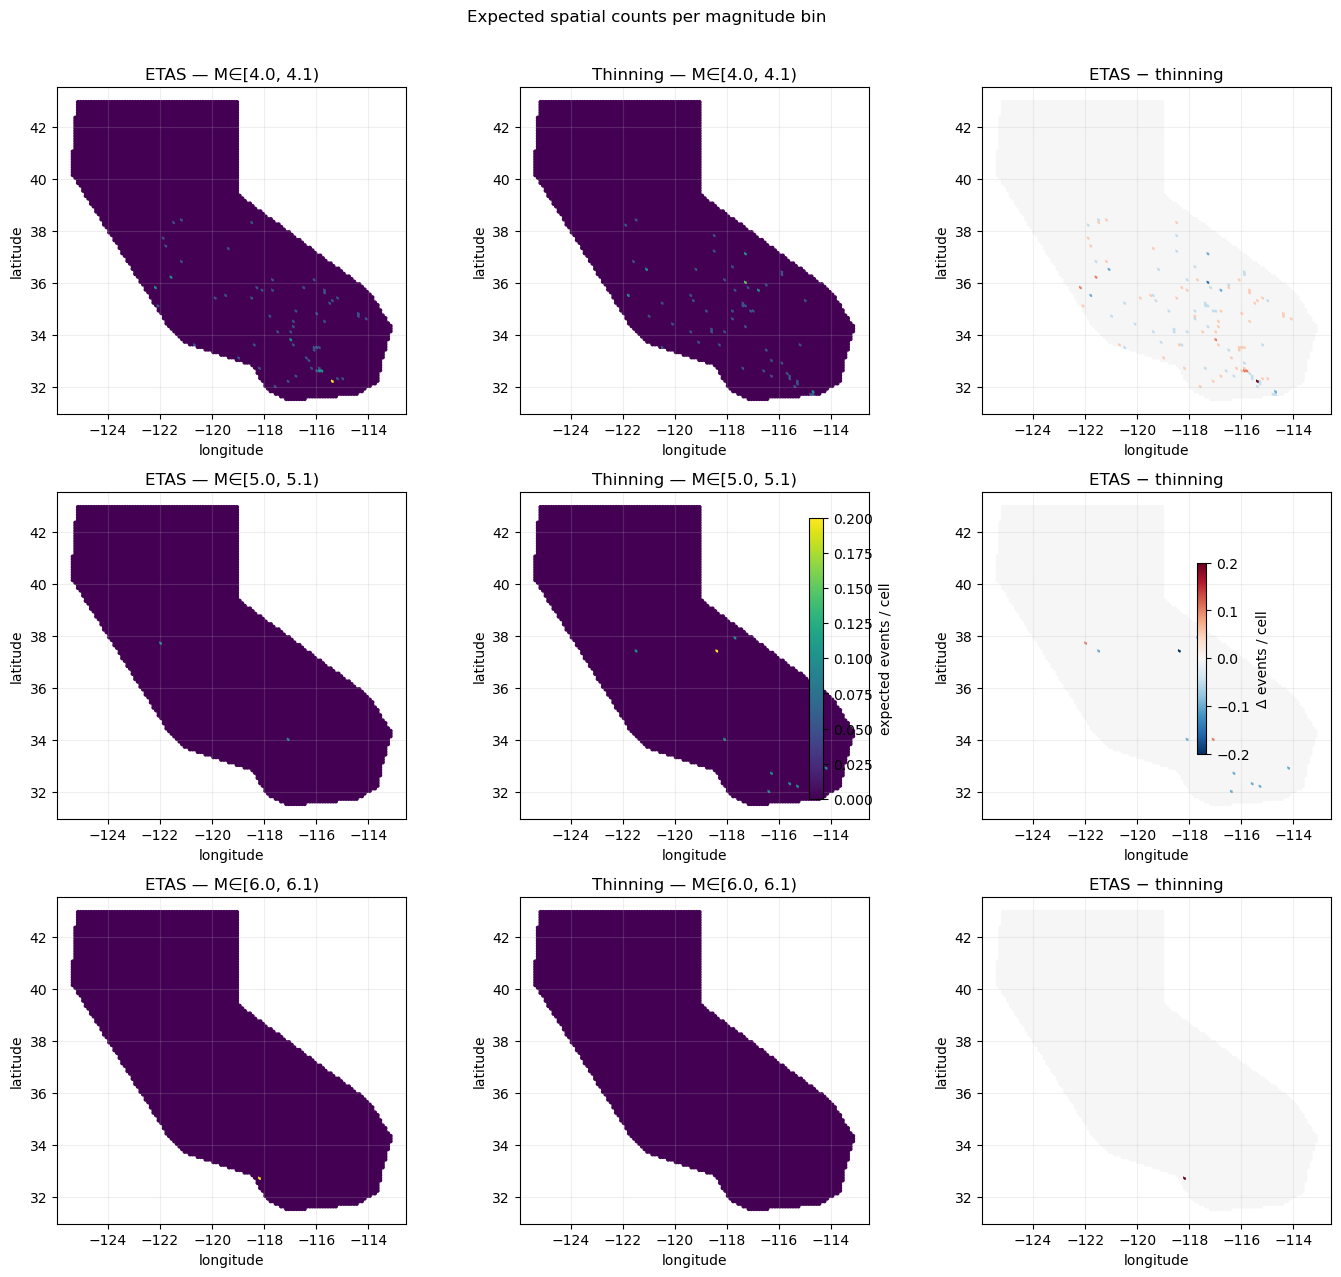

In [ ]:
# --- configure magnitude bin(s) to map ---
# Left edges from CSEP bins (e.g. 4.0 → events with 4.0 ≤ M < 4.1 when dmw=0.1).
MAG_BIN_LEFT_EDGES: list[float] | None = [4.0, 5.0, 6.0]

# Used only when MAG_BIN_LEFT_EDGES is None: sum all bins whose left edge lies in [lo, hi].
MAG_RANGE: tuple[float, float] = (4.0, 5.0)


def _mag_bin_indices(mag_left_edges: np.ndarray, targets: list[float]) -> list[int]:
    idx = []
    for m in targets:
        j = int(np.searchsorted(mag_left_edges, m, side="left"))
        if j >= len(mag_left_edges) or not np.isclose(mag_left_edges[j], m):
            raise ValueError(f"{m} is not a CSEP magnitude bin left edge; nearest bins: {mag_left_edges[max(j-1,0):j+2]}")
        idx.append(j)
    return idx


def expected_spatial_for_mag_bins(expected, mag_indices: list[int]) -> np.ndarray:
    """Sum expected spatial counts over the selected magnitude columns."""
    if not mag_indices:
        return np.zeros(expected.data.shape[0])
    return expected.data[:, mag_indices].sum(axis=1)


mag_left = np.asarray(etas_expected.magnitudes, dtype=float)
dmw = mag_left[1] - mag_left[0]

if MAG_BIN_LEFT_EDGES is not None:
    mag_targets = MAG_BIN_LEFT_EDGES
else:
    lo, hi = MAG_RANGE
    mag_targets = [m for m in mag_left if lo <= m <= hi]
    if not mag_targets:
        raise ValueError(f"No CSEP bins in MAG_RANGE={MAG_RANGE}")

mag_indices = _mag_bin_indices(mag_left, mag_targets)
lons, lats = csep_region.midpoints().T

n_rows = len(mag_targets)
fig, axes = plt.subplots(n_rows, 3, figsize=(14, 4.2 * n_rows), squeeze=False)

for row, (mag_edge, mag_idx) in enumerate(zip(mag_targets, mag_indices)):
    etas_slice = expected_spatial_for_mag_bins(etas_expected, [mag_idx])
    thin_slice = expected_spatial_for_mag_bins(thin_expected, [mag_idx])
    diff_slice = etas_slice - thin_slice

    vmax = max(etas_slice.max(), thin_slice.max(), 1e-12)
    vabs = max(np.abs(diff_slice).max(), 1e-12)

    sc0 = axes[row, 0].scatter(lons, lats, c=etas_slice, s=5, cmap="viridis", vmin=0, vmax=vmax)
    axes[row, 0].set_title(f"ETAS — M∈[{mag_edge:.1f}, {mag_edge + dmw:.1f})")
    axes[row, 1].scatter(lons, lats, c=thin_slice, s=5, cmap="viridis", vmin=0, vmax=vmax)
    axes[row, 1].set_title(f"Thinning — M∈[{mag_edge:.1f}, {mag_edge + dmw:.1f})")
    sc2 = axes[row, 2].scatter(
        lons, lats, c=diff_slice, s=5, cmap="RdBu_r", vmin=-vabs, vmax=vabs,
    )
    axes[row, 2].set_title("ETAS − thinning")

    for ax in axes[row]:
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.2)

    # Marginal check: sum over space == magnitude_counts()[bin]
    print(
        f"M∈[{mag_edge:.1f}, {mag_edge + dmw:.1f}): "
        f"spatial sum ETAS={etas_slice.sum():.4f} (marginal={etas_expected.magnitude_counts()[mag_idx]:.4f}), "
        f"thinning={thin_slice.sum():.4f} (marginal={thin_expected.magnitude_counts()[mag_idx]:.4f})"
    )

fig.colorbar(sc0, ax=axes[:, :2].ravel().tolist(), fraction=0.02, pad=0.02, label="expected events / cell")
fig.colorbar(sc2, ax=axes[:, 2].ravel().tolist(), fraction=0.03, pad=0.02, label="Δ events / cell")
fig.suptitle("Expected spatial counts per magnitude bin", fontsize=12, y=1.01)
fig.tight_layout()
show_fig(fig)
